<a href="https://colab.research.google.com/github/isouravsengupta/ai-data-engineer-handbook/blob/main/TopQS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Max Product of Three Numbers in an Array.

In [ ]:
def max_product_of_three(nums):
    nums.sort()  # Sort in ascending order
    n = len(nums)

    # Case 1: All numbers are positive
    product1 = nums[-1] * nums[-2] * nums[-3]

    # Case 2: Two numbers are negative
    product2 = nums[0] * nums[1] * nums[-1]

    return max(product1, product2)

# Example usage:
# nums = [-1, -2, -3, -4, -5]
nums = [1, 3, 5, 2, 8, 0, -1, -3 ]
nums = [0, -1, 3, 100, -70, -50]
result = max_product_of_three(nums)
print(result)  # Output: 60

350000


# Nearest Smaller Number on the Right

In [ ]:
Arr = [7,9,3,5,8,11,6]
n = len(Arr)
ans=[0]*n
stack= []
for i in range(n-1, -1, -1):
  # pop all greater or equal elements then current element
  while(len(stack) > 0 and stack[len(stack)-1] >= Arr[i]):
    stack.pop()

  # update the answer
  if len(stack) < 1:
    ans[i] = -1
  else:
    ans[i] = stack[len(stack)-1]

  # add the current element into the stack
  stack.append(Arr[i])

print(ans)


[3, 3, -1, -1, 6, 6, -1]


# Find the largest area of rectangle(formed by continuous bars) in histogram.

In [ ]:
arr = [8,6,2,5,6,5,7,4]
# for each element what is the area possible. Get max of it.
# one element width can go as far as a elemnt on the left side is present of its width, same for the right side.
# same we can say before the nearest smaller on the left and then on the right

# Nearest smaller on the left
stack = []
NSL = []
n = len(arr)
for i in range(n):
  # pop all the greater or equal elements
  while(len(stack) > 0 and arr[stack[len(stack)-1]] >= arr[i]):
    stack.pop()

  # update the answer
  if len(stack) < 1:
    NSL.append(-1)
  else:
    NSL.append(stack[len(stack)-1])

  # insert the current element into the stack
  stack.append(i)

# Nearest Smaller Element on the right
stack = []
NSR = [0]*n
for i in range(n-1,-1,-1):

  # pop all the greater or smaller element
  while(len(stack)>0 and arr[stack[len(stack)-1]] >= arr[i]):
    stack.pop()

  # update the answer
  if len(stack) < 1:
    # here not storing -1 but len to het the right width
    NSR[i] = n
  else:
    NSR[i] = stack[len(stack)-1]

  # insert the current element into the stack
  stack.append(i)

print('NSL:', NSL)
print('NGR:', NSR)
ans = -1
# finding the largest area
for i in range(n):
  ans = max(ans, arr[i]* (NSR[i]-NSL[i]-1))

print('Largest area of rectangle:',ans)

NSL: [-1, -1, -1, 2, 3, 2, 5, 2]
NGR: [1, 2, 8, 7, 5, 7, 7, 8]
Largest area of rectangle: 20


# Find the sum of (Max - Min) for all sub-arrays

In [ ]:
arr =[1,2,3]
# Find: sum of max - sum of min

# In how many sub-arrays one element will be max. I.e Untill a greater number on its right as well as on its left

# Nearest Greater on the Left
stack = []
NGL = []
n = len(arr)

for i in range(n):
  # pop all the smaller or equal elements
  while(len(stack) > 0 and arr[stack[len(stack)-1]] <= arr[i]):
    stack.pop()

  # update the answer
  if len(stack) < 1:
    NGL.append(-1)
  else:
    NGL.append(stack[len(stack)-1])

  # update the stack
  stack.append(i)

# Nearest Greater on the Right
stack = []
NGR = [0]*n

for i in range(n-1, -1, -1):

  # pop all the smaller or equal elements
  while(len(stack)>0 and arr[stack[len(stack)-1]] <= arr[i]):
    stack.pop()

  # update the answer
  if len(stack) < 1:
    NGR[i] = n
  else:
    NGR[i] = arr[i]

  # update the stack
  stack.append(i)

# Nearest Smaller on the Left
stack = []
NSL = []
n = len(arr)

for i in range(n):
  # pop all the greater or equal elements
  while(len(stack) > 0 and arr[stack[len(stack)-1]] >= arr[i]):
    stack.pop()

  # update the answer
  if len(stack) < 1:
    NSL.append(-1)
  else:
    NSL.append(stack[len(stack)-1])

  # update the stack
  stack.append(i)

# Nearest Smaller on the Right
stack = []
NSR = [0]*n

for i in range(n-1, -1, -1):

  # pop all the greater or equal elements
  while(len(stack)>0 and arr[stack[len(stack)-1]] >= arr[i]):
    stack.pop()

  # update the answer
  if len(stack) < 1:
    NSR[i] = n
  else:
    NSR[i] = arr[i]

  # update the stack
  stack.append(i)

sum_max = 0
sum_min = 0

for i in range(n):
  sum_max += (arr[i] * ((NGR[i]-i)*(i-NGL[i])))
  sum_min += (arr[i] * ((NSR[i]-i)*(i-NSL[i])) )

ans = sum_max - sum_min

print(ans)

4


# Sliding Window Maximum
### Find max of every subarray of size K.

In [ ]:
arr = [3,2,3,4,5,5,4,5,6]
k = 4
# max of one window can be max of next N windows until that max is present in that window and addition of new element in the window is not max

# Algo: use doubly ended queue (deque)
# 1. Find maximum in the first window and store the index in the deque and update the ans list.
# 2. For every next window's new element - keep popping all the smaller element from top compared to the new element. Insert the current element.
# 3. if Bottom of the dequeu element is in the window, then that is the max element else pop the bottom element and update the answer.



# Count of Triplets in an array less than a Number X
### Given Array is sorted in the ascending order

In [ ]:
arr = [1,2,3,5,7]
target = 15
n = len(arr)
i = 0
j = 1
k = n-1

cnt = 0
while(i < n-2 ):
  # re-set the value of j and k for new i
  j = i+1
  k = n-1
  while(j<k):
    if arr[i]+arr[j]+arr[k] < target:
      # get count of no of triplets less than the target
      cnt += k-j
      j += 1
    else:
      # reduce k
      k -= 1
  i += 1

print(cnt)


9


# Pascal Triangle

In [ ]:
n = 7
op = []
for i in range(5):
  row = []
  for j in range(i+1):
    if j == 0 or (i == j):
      row.append(1)
    else:
      # nCr = n-1Cr + n-1Cr-1
      row.append( op[i-1][j] + op[i-1][j-1] )
  op.append(row)
print(op)

[[1], [1, 1], [1, 2, 1], [1, 3, 3, 1], [1, 4, 6, 4, 1]]


# Nth olumn Title

In [ ]:
n = 104
op = ''

while(n != 0):
  r = n%26
  n = n // 26

  if r == 0:
    r = 26
    n -= 1
  op = chr(ord('A')+r-1)+op
op

'CZ'

In [ ]:
class Solution:
    def solve(self, A, B, C):
        row = []
        for i in range(A+1):
            curr_row = []
            for j in range(i+1):
                if j == 0 or i == j:
                    curr_row.append(1)
                else:
                    curr_row.append(row[j-1]+row[j])
            row = curr_row
        return row[B]

In [ ]:
obj = Solution()
obj.solve(6,2,10)

row:  []
curr_row:  [1]
row:  [1]
curr_row:  [1, 1]
row:  [1, 1]
curr_row:  [1, 2, 1]
row:  [1, 2, 1]
curr_row:  [1, 3, 3, 1]
row:  [1, 3, 3, 1]
curr_row:  [1, 4, 6, 4, 1]
row:  [1, 4, 6, 4, 1]
curr_row:  [1, 5, 10, 10, 5, 1]
row:  [1, 5, 10, 10, 5, 1]
curr_row:  [1, 6, 15, 20, 15, 6, 1]


15

# Count Number of 1s.

In [ ]:
def solve(A):
  ans = 0
  num = A
  base = 1

  while(num != 0):
    num = num//10

    left = A // (base * 10)
    current = (A//base)%10
    right = A % base

    if current == 1:
      ans += (left*base)+(right+1)
    elif current == 0:
      ans += left*base
    else:
      ans += (left+1)*base
    base *= 10
  return ans

# function Call
solve(145)

81

# Decode the String


---


**Problem Description:**
  You are given an encoded string A of length N consisting of digits and lowercase English letters. Your task is to decode the string and return the decoded version.
  The encoding rule is as follows:
  for every substring in the form of k[encoded_ string],
  where k is a positive integer and encoded_string is any valid encoded string (it can also include other encoded substrings), you need to repeat the encoded_string exactly k times if k is greater than B else keep it once.

  **Problem Constraints**
  1<=N<=50
  1 <= k, B <= 100
  Alil consists only of digits, lowercase English letters, and square brackets

  **Input Format**
  First argument is the encoded string A Second Argument is an integer B

  **Output Format**
  Return the decoded version of the input string, which contains only lowercase English letters

  **Example Input**

  Input 1:
  A = 3[a]2[cf]
  B = 2

  Input 2:
  A = 2[4[b]a]
  B = 5

  **Example Output**

  Output 1: aaacf

  Output 2: ba

In [ ]:
### TO DO

# Sieve of Eratosthenes
Iterate on all numbers from 1 to N and check if it is prime or not.


In [ ]:
n= 50
num_list = []

for i in range(n+2):
  num_list.append(i)

is_prime = [True]*51

is_prime[0] = False
is_prime[1] = False

# for i in range(2,n+1//2):
#   if is_prime[i] == True:
#     for j in range(i+i,n+1,i):
#       is_prime[j] = False

i = 2

while(i*i < n+1):
  if is_prime[i] == True:
    for j in range(i*i,n+1,i):
      is_prime[j] = False
  i += 1

for i in range(n+1):
  print(f'{i} : {is_prime[i]}')




# Number of divisors/factors of 1 to N

In [ ]:
n = 100
num_list = []
for i in range(n+2):
  num_list.append(i)

op_list = [1]*(n+1)

i = 2
while(i < n+1):
  for j in range(i, n+1, i):
    op_list[j] += 1
  i += 1

for i in range(n+1):
  print(f'{num_list[i]}: {op_list[i]}')

# Get first Prime Factor of Each Number till N

In [ ]:
n = 10
first_prime = []
for i in range(n+2):
  first_prime.append(i)

i = 2

while(i*i < n+2):
  for j in range(i*i, n+2, i):
    if first_prime[j] == j:
      first_prime[j] = i
  i += 1
first_prime



[0, 1, 2, 3, 2, 5, 2, 7, 2, 3, 2, 11]

# <!-- Rough -->
# Check two bracket expressions

In [ ]:
s1 = '-(a-(b+c))'
s2 = '-a+b-c'

op1 = [True]*26
op2 = [True]*26

n1 = len(s1)
gv = True
for i in range(n1):
  if s1[i] == '(' and i-1 !=0:
    if s1[i-1] == '-':
      gv = not gv
  elif ord(s1[i]) >=97 and ord(s1[i]) <=122:
    if s1[i-1] == '-':
      if gv:
        print(ord(s1[i]))
        print(gv)
        op1[ord(s1[i])-97] = False
    else:
      if not gv:
        op1[ord(s1[i])-97] = False
print(op1)

[True, False, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


# Generate all the combinations of well-formed parenthesis of lenght 2 X A.
Backtracking

In [ ]:
def parenthesis(st, OBC, CBC, A):
  if len(st) == 2*A:
    print(st)
    return
  if OBC < A:
    parenthesis(st+'(', OBC+1, CBC, A)
  if OBC >  CBC:
    parenthesis(st+')', OBC, CBC+1, A)

# call the parenthesis function
# OBC : Opening Bracket Count
# CBC : Closing Bracket Count
st =''
OBC = 0
CBC = 0
A = 3
parenthesis(st, OBC, CBC, A)

((()))
(()())
(())()
()(())
()()()


# Generate all the sub-sets using recursion.
`Backtraking`

In [ ]:
def generate(arr, indx, curr, op):
  if indx == len(arr):
    ans = curr.copy()
    op.append(ans)
    return
  # I don't want to add so go to the next element
  generate(arr, indx+1, curr, op)
  # I want to add, so add in the current
  curr.append(arr[indx])
  # GO to the next element
  generate(arr, indx+1, curr, op)
  curr.pop(len(curr)-1)

# CALL the generator
arr = [1,2,3]
indx = 0
curr = []
op =[]
generate(arr, indx, curr, op)
print(op)

[[], [3], [2], [2, 3], [1], [1, 3], [1, 2], [1, 2, 3]]


# Given a string with distinct elements. Print all permutations of it without modifying it.

*Backtracking*

In [ ]:
def permutation(st, indx, st_ans, is_used):
  if indx == len(st):
    print(st_ans)
    return
  for i in range(len(st)):
    if is_used[i] == False:
      is_used[i] = True
      permutation(st, indx+1, st_ans+st[i], is_used)
      is_used[i] = False

# FUNCTION CALL
st = 'abc'
# Keep track of used elements
# For which spot we are deciding who can take this spot. Spot can only be taken by elements which are not used
indx = 0
st_ans = ''
# which character has been used . like a _ _ , a has been used and next spot at index 1 can be taken by either b or c.
is_used = [False]*len(st)
permutation(st, indx, st_ans, is_used)

abc
acb
bac
bca
cab
cba


# Print all paths from Source to Destination.
### Board: A x B. Start: Top left corner. Dest: Bottom right corner.
*`Backtracking`*

In [ ]:
def traverse(i, j, p, q, curr,op):
  if i == p and j== q:
    op.append(curr)
    return

  if i < p:
    curr += 'D'
    traverse(i+1, j, p, q, curr,op)

  if j < q:
    curr += 'R'
    traverse(i, j+1, p, q, curr,op)

In [ ]:
i = 0
j = 0
p = 2
q = 1
is_trav = []
curr = ''
op = []
traverse(i, j, p, q, curr, op)
print(op)


['DDR', 'DDRD', 'DRDD']


# Print all the paths in a Binary Maze with Hurdles

In [ ]:
def traverse(A, sr, sc, dr, dc, curr, is_trav, curr_dis, min_dis):
  if sr < 0 or sc < 0 or sr >= len(A)  or sc >= len(A) or A[sr][sc] == 0 or is_trav[sr][sc] == True:
    return

  if sr == dr and sc == sc:
    min_dis = min(min_dis,curr_dis)
    print(curr)
    print(min_dis)
    return

  is_trav[sr][sc] = True

  # move upward
  traverse(A, sr-1, sc, dr, dc, curr+'U', is_trav, curr_dis+1, min_dis)
  # move left
  traverse(A, sr, sc-1, dr, dc, curr+'L', is_trav, curr_dis+1, min_dis)
  # move downward
  traverse(A, sr+1, sc, dr, dc, curr+'D', is_trav, curr_dis+1, min_dis)
  # move right
  traverse(A, sr, sc+1, dr, dc, curr+'R', is_trav, curr_dis+1, min_dis)

  is_trav[sr][sc] = False

# >>>>>  Function Call
A = [[1, 1, 0, 0],
     [0, 1, 1, 0],
     [0, 0, 1, 1],
     [0, 0, 0, 1]]

is_trav = []
for i in range(len(A)):
  is_trav.append([False]*len(A[0]))
# source row
sr = 0
# source col
sc = 0

# dest row
dr = 0
# dest col
dc = 2
curr_dis = 0
min_dis = float('inf')
traverse(A, sr, sc, dr, dc, '', is_trav, curr_dis, min_dis)
print('Minimum Distance: ',min_dis)


0
Minimum Distance:  inf


# Create Linked List from a List

In [ ]:
class ListNode:
  def __init__(self, x):
    self.val = x
    self.next = None


def list_to_linked_list(lst):
  head = ListNode(lst[0])
  temp = head
  for i in range(1,len(lst),1):
    temp.next = ListNode(lst[i])
    temp = temp.next
  return head

def linked_list_to_list(head):
  lst = []
  temp = head
  while(temp):
    lst.append(temp.val)
    temp = temp.next
  return lst

# Middle of a Linked-List

In [ ]:
def get_middle_node(head):
  fast, slow = head, head
  # fast.next will become None in Odd Size list and fast.next.next will become None in Even size list
  while(fast.next and fast.next.next):
    slow = slow.next
    fast = fast.next.next
  return slow

####
# Odd size list
# lst = [10, 3, 7, 9, 5, 4 , 11]
# Even size list
lst = [10, 3, 7, 9, 5, 4 , 11, 16]

# create link list
head = list_to_linked_list(lst)
mid_node = get_middle_node(head)
print(mid_node.val)

9


# Merge Two Sorted Linked-List

In [ ]:
def merge_two_link_list(head1, head2):

  if head1.val < head2.val:
    head = head1
    head1 = head1.next
  else:
    head = head2
    head2 = head2.next

  temp = head

  while(head1 and head2):
    if head1.val < head2.val:
      temp.next = head1
      temp = head1
      head1 = temp.next
    else:
      temp.next = head2
      temp = head2
      head2 = temp.next

  if not head1:
    temp.next = head2
  else:
    temp.next = head1

  return head

# Function Call
lst1 = [2,6,10,14,19]
lst2 = [3,5,9,11]
head1 = list_to_linked_list(lst1)
head2 = list_to_linked_list(lst2)
head = merge_two_link_list(head1, head2)
print(linked_list_to_list(head))



[2, 3, 5, 6, 9, 10, 11, 14, 19]


# Merge Sort a Linked-List

In [ ]:
def merge_sort(head):
  if not head or not head.next :
    return head
  mid = get_middle_node(head)
  head2 = mid.next
  mid.next = None
  head = merge_sort(head)
  head2 = merge_sort(head2)
  return merge_two_link_list(head, head2)

# function call
lst = [10,3,7,9,5,4,11]
head = list_to_linked_list(lst)
head = merge_sort(head)
print(linked_list_to_list(head))


[3, 4, 5, 7, 9, 10, 11]


# Reverse a Linked List

In [ ]:
def reverse_linked_list(head):
  prev = None
  curr = head

  while(curr):
    temp = curr.next
    curr.next = prev
    prev = curr
    curr = temp

  return prev

lst = [1,2,3,4,5]
head = list_to_linked_list(lst)
head = reverse_linked_list(head)
print(linked_list_to_list(head))

[5, 4, 3, 2, 1]


# Add two linked list with each of their nodes contains a single digit.
`Error - To Do`





In [ ]:
lst1 = [9,9]
lst2 = [1]

head1 = list_to_linked_list(lst1)
head2 = list_to_linked_list(lst2)

t1 = head1
t2 = head2
carry = 0
while(t1 or t2):
  if t1:
    x = t1.val
  else:
    x = 0

  if t2:
    y = t2.val
  else:
    y = 0

  t_sum = x+y+carry
  if t1.next or t2.next:
    sm = t_sum % 10
  else:
    sm = t_sum
  carry = t_sum // 10

  if t1:
    t1.val = sm
  else:
    t1.next = t2

  if t1:
    t1 = t1.next
  if t2:
    t2 = t2.next

print(linked_list_to_list(head1))


AttributeError: 'NoneType' object has no attribute 'next'

# Create a Tree using a list denoting a Level Order Traversal

In [ ]:
# lst = [6, 9, 4, -1, -1, 8, -1, -1, 3, -1, -1]

class TreeNode:
   def __init__(self, x):
       self.val = x
       self.left = None
       self.right = None

def get_tree(lst):
  queue = []
  root = TreeNode(lst[0])
  queue.append(root)
  i = 0
  while(len(queue) > 0):
    # pop from queue to get current parent
    parent = queue.pop(0)

    # check if the left child exists
    if lst[i+1] != -1:
      left_child = TreeNode(lst[i+1])
      parent.left = left_child
      # next parent to be
      queue.append(left_child)

    # check if the right child exists
    if lst[i+2] != -1:
      right_child = TreeNode(lst[i+2])
      parent.right = right_child
      # next parent to be
      queue.append(right_child)

    i += 2

  return root


# Inorder traversal of Tree


In [ ]:
def in_order_traversal(root, op):
  if root == None:
    return op
  in_order_traversal(root.left, op)
  op.append(root.val)
  in_order_traversal(root.right, op)

# test
# lst = [1, 2, 3, 4, 5, -1, -1, -1, -1, -1, -1]

lst = [1,2,3,-1,-1,-1,-1]
root = get_tree(lst)
op = []
in_order_traversal(root, op)
op

[2, 1, 3]

# Diameter of binary tree

In [ ]:
class Solution:
    def inorder(self, root):
        if not root:
            return 0
        l = self.inorder(root.left)
        r = self.inorder(root.right)
        self.ans = max(self.ans, l+r)
        return max(l,r)+1

    def solve(self, A):
        self.ans = -1
        self.inorder(A)
        return self.ans

lst = [1, 15, 2, -1, -1, -1, -1]
root = get_tree(lst)
obj = Solution()
op = obj.solve(root)
print(op)

2


# Kth Smallest element in BST

**Problem Description**

Given a binary search tree represented by root A, write a function to find the Bth smallest element in the tree.

**Example Input**

Input 1:


            2
          /   \
         1    3
B = 2
Input 2:


            3
           /
          2
         /
        1
B = 1



**Example Output**

Output 1:

 2
Output 2:

 1

In [ ]:
# using the extra space to store the list
lst = lst = [10,5,20,2,8,15,30,-1,-1,6,-1,-1,18,-1,-1,-1,7,16,19,-1,-1,-1,-1,-1,-1]
root = get_tree(lst)

op = []
in_order_traversal(root, op)
print(op[7])

16


In [ ]:
# NOT using the space to store the list
class Solution:
    def find_Kth(self, root, B, found):
        if not root:
            return

        if not found:
            self.find_Kth(root.left, B, found)
            self.cntr += 1
            if self.cntr == B:
                found = True
                self.ans = root.val
        if not found:
            self.find_Kth(root.right, B,found)




	def kthsmallest(self, A, B):
        self.cntr, self.ans = 0, 0
        self.find_Kth(A, B, False)
        return self.ans

## Lowest Common Ancestor (LCA)

In [ ]:
class abc:
  def get_lca(self, root, val1, val2):
        if not root:
            return None
        if root.val == val1 or root.val == val2:
            return root.val

        left =  self.lca(root.left, val1, val2)
        right = self.lca(root.right, val1, val2)

        if left is not None and right is not None:
            return root.val
        if left is not None:
            return left
        else:
            return right

  def find_node(self, root, val):
    if not root:
      return False
    if root.val == val:
      return True
    return self.find_node(root.left, val) or self.find_node(root.right, val)
    # if not root:
    #   return False
    # return self.find_node(root.left, val)
    # if root.val == val:
    #   return True
    # return self.find_node(root.right, val)

  def lca(self, root, p, q):
    p_isPrsent = self.find_node(root, p)
    print(p_isPrsent)

    q_isPrsent = self.find_node(root, q)
    print(q_isPrsent)

    if not p_isPrsent or not q_isPrsent:
      return -1

    return self.get_lca(root, p, q)



lst = [1,2,3,4,5,-1,-1,-1,-1,-1,-1]

root = get_tree(lst)
obj = abc()
op = obj.lca(root, 4, 5)
op

True
True
True
True
True
False
False
True
False
False


1

# Next Pointer Binary Tree

In [ ]:
class TreeLinkNode:
    def __init__(self, x):
        self.val = x
        self.left = None
        self.right = None
        self.next = None

def get_tree_next(lst):
  queue = []
  root = TreeNode(lst[0])
  queue.append(root)
  i = 0
  while(len(queue) > 0):
    # pop from queue to get current parent
    parent = queue.pop(0)

    # check if the left child exists
    if lst[i+1] != -1:
      left_child = TreeNode(lst[i+1])
      parent.left = left_child
      # next parent to be
      queue.append(left_child)

    # check if the right child exists
    if lst[i+2] != -1:
      right_child = TreeNode(lst[i+2])
      parent.right = right_child
      # next parent to be
      queue.append(right_child)

    i += 2

  return root

# Function Calls
lst = [1, 2, 3, 4, 5, 6, 7, -1,-1,-1,-1, -1,-1,-1,-1]
root = get_tree_next(lst)
op = []
in_order_traversal(root, op)
print(op)

[4, 2, 5, 1, 6, 3, 7]


# Find a node in a tree

In [ ]:
def find_node(root, val):
  if not root:
    return False
  if root.val == val:
    return True
  return find_node(root.left, val) or find_node(root.right, val)

lst = [1,2,3,4,5,-1,-1,-1,-1,-1,-1]

root = get_tree(lst)
op = find_node(root, 4)
op

True

# Print sub-arrays with unique elements.
`-To Do`

In [ ]:
# TO DO

# Kadanes' algo : largest sub-array sum. Get L and R index.

In [ ]:
# [-2, 1, -3, 4, -1, 2, 1, -5, 4]

def kadane(lst):
  sm =0
  ans = lst[0]
  l = 0
  ans_l = 0
  r = 0

  for i in range(len(lst)):
    sm += lst[i]
    l =i
    if sm > ans:
      ans = sm
      ans_l = l
      r = i

    if sm < 0:
      sm = 0



  print('l= :', ans_l)
  print('r= :', r)
  return ans

# lst = [-1, 1, -1, 1, 1, -1, 1]
lst = [-2,  -3, -1, -5]
op = kadane(lst)

op

l= : 2
r= : 2


-1

# Next Permutation
Implement the next permutation, which rearranges numbers into the
numerically next greater permutation of numbers for a given array A of size N.
If such arrangement is not possible, it must be rearranged as the lowest possible order, i.e., sorted
in ascending order

In [ ]:
# A = [2,4,3]
A = [5,8,7,9,5,3]

# 1. find the first dip from right to left. 2. Swap the dip with the next immediate larger number than this on its right.
# 3. Sort the array from dip+1 till the last element in the ascending order.

# 1. Find the dip
n = len(A)
dip = -1
for i in range(n-1, 0, -1):
  if A[i-1] < A[i]:
    dip = i-1
    break

# 2. Find next immediate larger number
nxt_larger = -1
for i in range(n-1, dip, -1):
  if A[i] > A[dip]:
    nxt_larger = i
    break

# 3. Swap the dip and nxt_larger
temp = A[dip]
A[dip] = A[nxt_larger]
A[nxt_larger] = temp

# 4. Sort(reverse) the array from dip+1
i = dip+1
j = n-1

while(i<j):
  temp = A[i]
  A[i] = A[j]
  A[j] = temp
  i += 1
  j -= 1

print(A)



[5, 8, 9, 3, 5, 7]


# Find the first missing natural number.

In [ ]:
# A = [5, 3, 1, -1, -2, -4, 7, 2]
A = [4,2,7,6,9,1,5,3]

# Let's say if the length of the list is 5, then the first missing number will be between 1 to 5. If all the numbers between 1 to 5 is present, then
#  the first missing number will be 6, i.e n+1.

# approach: if element at i-th index is not equal to i+1 then swap the i-th index element with the (i-th element value - 1 )th index.
# Keep swapping untill i-th element value is >= i+1 itself.

n = len(A)
i = 0
while(i < n):
  if A[i] == i+1:
    i += 1
  elif A[i] > 0 and A[i] <= n:
    tmp = A[i]
    A[i] = A[tmp-1]
    A[tmp-1] = tmp
  else:
    i += 1

for i in range(n):
  if A[i] != i+1:
    print(i+1)
    break

8


# Learn Enumerate

In [ ]:
A = 'abcde'
for i, j in enumerate(A):
  print(i, j)

0 a
1 b
2 c
3 d
4 e


# Kth Distinct String in an Array

In [ ]:
class Solution(object):
    def kthDistinct(self, arr, k):
        mp ={}

        for s in arr:
            if s in mp:
                mp[s] += 1
            else:
                mp[s] = 1

        cntr = 0
        for key, val in mp.items():
            if val == 1:
                cntr += 1

            if cntr == k:
                return key
        return ""

obj = Solution()
arr = ["d","b","c","b","c","a"]
k = 2
op = obj.kthDistinct(arr, k)
op

'a'

In [ ]:
class Solution(object):
    def kthDistinct(self, arr, k):
        """
        :type arr: List[str]
        :type k: int
        :rtype: str
        """
        mp ={}

        for s in arr:
            if s in mp:
                mp[s] += 1
            else:
                mp[s] = 1

        cntr = 0
        for key, val in mp.items():
            if val == 1:
                cntr += 1
            if cntr == k:
                return key
        return ""

obj = Solution()
arr = ["d","b","c","b","c","a"]
k = 2
op = obj.kthDistinct(arr, k)
op

'a'

# Question
Given an integer array of size N, where all the elements occur thrice except one element. Find that unique element.

In [ ]:
arr =  [4 , 5 , 5 , 4 , 11 , 6 , 6 , 4 , 5 , 6]

n = len(arr)
ans = 0

for i in range(32):
    cnt = 0

    for j in range(n):
       if arr[j] & (1 << i) != 0:
            cnt += 1
    if cnt % 3 != 0:
        ans |= (1 << i)

print(ans)

11


# Question
Given an integer array of size N, where all elements repeat twice except two. Find those two elements.

In [ ]:
arr = [4 , 5 , 4 , 1 , 6 , 6 , 5 , 2 ]

# take xor of all the elements
arr_xor = 0

for e in arr:
    arr_xor ^= e

set_bit = -1
# find the set bit
for i in range(32):
    if arr_xor & (1 << i) != 0:
        set_bit = i
        break

n1, n2 = 0, 0

for e in arr:
    if e & (1 << set_bit) != 0:
        n1 ^= e
    else:
        n2 ^= e

print(n1, n2)

1 2


# dndk

In [ ]:
class Solution:
    def solve(self, A, B):
        fre_arr = [0]*B
        for i in range(len(A)):
            fre_arr[A[i]%B] += 1
        print('fre_arr: ', fre_arr)
        ans = 0

        if (B-1)%2 != 0:
            n = fre_arr[B//2]
            ans += (n * (n-1))//2

        for i in range(B//2):
            if i == 0:
                ans += (fre_arr[i] * (fre_arr[i]-1) )//2
            else:
                ans += fre_arr[i] * fre_arr[B-i]

        return ans % (10**9+7)


onj = Solution()
# A = [1,2,3,4,5]
# B = 2

# A = [5, 17, 100, 11]
# B = 28

A = [10,23,94,30,25,67,54,30,18,54,70,92,94,92,39,77,53,8,54,55,93,30,98,75,35,45,32,25,77,50,56,80,57,55,82,90,78,96,7,75,93,50,62,91,11,86,5,52,28,36,37,78,89,74,47,15,76,29,41,63,10,53,42,100,30,63,58,38,95,60,79,30,71,24,67,23,94,29,42,43,23,1,82,66,85]
B = 43

# A = [2, 3, 4, 8, 6, 15, 5, 12, 17, 7, 18, 10, 9, 16, 21 ]
# B = 6
op = onj.solve(A, B)
op

fre_arr:  [2, 1, 1, 1, 2, 2, 2, 5, 4, 2, 5, 4, 3, 1, 2, 2, 0, 1, 1, 1, 2, 0, 0, 4, 3, 2, 0, 1, 2, 2, 5, 1, 3, 1, 2, 3, 2, 2, 1, 3, 0, 1, 3]


89

# Count the number of pairs with sum = K

In [ ]:
arr =  [ 2, 5, 2, 5, 8, 5, 2, 8 ]
K = 10

n = len(arr)
dct = dict()
cnt = 0
for i in range(n):
    diff = K - arr[i]

    if diff in dct:
        cnt += dct[diff]

    if arr[i] in dct:
        dct[arr[i]] += 1
    else:
        dct[arr[i]] = 1
print(cnt)

9


# Merge Two Sorted Arrays

In [ ]:
# ToDO

# Dutch National Flag
Problem Description

Given an array with N objects colored red, white, or blue, sort them so that objects of the same color are adjacent, with the colors in the order red, white, and blue.

We will represent the colors as,

red -> 0
white -> 1
blue -> 2

In [ ]:
# ToDo

# join int list to create a string

In [ ]:
A = [89, 8]
A = [str(e) for e in A]
op = ''.join(A)
op

'898'

# Partion the array based on the last element of the array.
Given an integer array A of length N, considering the last element as pivot p, rearrange the elements such that for all i:

if A[i] < p then it should be present on left side of the partition
if A[i] > p then it should be present on right side of the partition

In [ ]:
def partition(arr):
    n = len(arr)
    i = 0
    j = n-2
    pvt = arr[n-1]
    while(i <= j):
        if arr[i] <= pvt:
            i += 1
        elif arr[j] > pvt:
            j -= 1
        else:
            tmp = arr[i]
            arr[i] = arr[j]
            arr[j] = tmp

            i += 1
            j -= 1
        tmp = arr[i]
        arr[i] = arr[n-1]
        arr[n-1] = tmp
    print('partition index: ',i)
    print('Re-arraged array: ',arr)

partition([6, 2, 0, 4, 5])

partition index:  3
Re-arraged array:  [4, 5, 2, 0, 6]


# Missing Two numbers
Given an array A of length N where all the elements are distinct and are in the range [1, N+2]. Two numbers from the range [1, N+2] are missing from the array A. Find the two missing numbers.

In [ ]:
arr = [2, 5, 4, 8, 1, 6]
# Approach - create an array of 1-N+2 + input array elements. Then find the XOR of all the elements.
n = len(arr)+2
new_arr = [0]*n

for i in range(len(arr)+2):
    new_arr[i] = i+1
new_arr = new_arr+arr

xor = 0
for e in new_arr:
    xor ^= e

#find first set bit
set_bit = -1
for i in range(32):
    if xor & (1 << i) != 0:
        set_bit = i
        break

n1, n2 = 0, 0

for e in new_arr:
    if e & (1 << set_bit) != 0:
        n1 ^= e
    else:
        n2 ^= e

print(f'Missing numbers are {n1} and {n2}.')

Missing numbers are 7 and 3.


# Maximum and pair
Given N array elements, choose two indices(i, j) such that (i != j) and (arr[i] & arr[j]) is maximum.

In [ ]:
arr = [26, 13, 23, 28, 27, 7, 25]
ans = 0

def delete(arr, bit_pos):
    new_arr = [num for num in arr if num & (1 << bit_pos) != 0]
    arr[:] = new_arr

for i in range(31, -1, -1):
    set_bit_cnt = 0
    for e in arr:
        if e & (1 << i) != 0:
            set_bit_cnt += 1
    if set_bit_cnt > 1:
        ans |= (1 << i)
        delete(arr, i)

print(ans)
print(arr)




26
[26, 27]


# Rotated Sorted Array Search

In [ ]:
class Solution:
    def search(self, A, B):
        l, r = 0, len(A)-1

        while(l <= r):
            mid = l + (r-l)//2

            if B >= A[0] and A[mid] >= A[0]:
                # target mid in part 1
                if A[mid] == B:
                    return mid
                if A[mid] > B:
                    r = mid-1
                else:
                    l = mid+1
            elif B < A[0] and A[mid] < A[0]:
                # target and mid in part 2
                if A[mid] == B:
                    return mid
                if A[mid] > B:
                    r = mid-1
                else:
                    l = mid+1
            elif B >= A[0] and A[mid] < A[0]:
                # target in part1 and mid in part2
                # move mid to left
                r = mid-1
            else:
                l = mid+1
        return -1

obj = Solution()
op = obj.search([5,1,3],5)
op

[26, 13, 28, 27, 7, 25]

# Matrix Median

Given a matrix of integers A of size N x M in which each row is sorted.
Find and return the overall median of matrix A.
NOTE: No extra memory is allowed.

In [ ]:
"""
    [[1, 3, 5],
     [2, 6, 9],
     [3, 6, 9]]
"""

def get_max_in_row( A, val):
    l,r = 0, len(A)-1
    ans = -1
    while(l <= r):
        mid = l + (r-l)//2

        if A[mid] > val:
            ans = mid
            r = mid-1
        else:
            l = mid+1

    if ans == -1:
        return len(A)
    else:
        return ans

def _median(A):
    rows = len(A)
    cols = len(A[0])


    l = 0
    r = max([A[i][cols-1] for i in range(rows)])

     # The median is Greater Than or Equal to  N//2+1 Elements in the array
    max_cnt = (rows * cols) // 2 +1

    while (l <= r):
        mid = l +(r-l)//2

        total_cnt = 0
        for row in range(rows):
            total_cnt += get_max_in_row(A[row], mid)

        if total_cnt >= max_cnt:
            ans =  mid
            r = mid-1
        else:
            l = mid+1
    return ans




arr =   [[1, 3, 5],
     [2, 6, 9],
     [3, 6, 9]]

median = _median(arr)
print(median)


# Find The Three Sum

In [ ]:
def find_three_sum(A, B):
    n = len(A)
    A.sort()

    i=0
    while(i < n-2):
        j = i+1
        k = n-1

        while(j<k):
            if A[i]+A[j]+A[k] == B:
                return True
            elif A[i]+A[j]+A[k] < B:
                j += 1
            else:
                k -= 1
        i += 1
    return False

A = [2, 4, 3, 2]
B = 9
op = find_three_sum(A,B)
op

# Find Smallest Again
Given an integer array A of size N.

If we store the sum of each triplet of the array A in a new list, then find the Bth smallest element among the list.

NOTE: A triplet consists of three elements from the array. Let's say if A[i], A[j], A[k] are the elements of the triplet then i < j < k.

In [ ]:
class Solution:
    def check(self,A, B, sm):
        n = len(A)
        i=0
        cnt = 0
        for i in range(n - 2):
            j = i+1
            k = n-1
            while (j < k):
                if A[i]+A[j]+A[k] < sm:
                    cnt += k-j
                    j += 1
                else:
                    k -= 1

        return cnt < B

    def solve(self, A, B):
        A.sort()
        min_sum = A[0] + A[1] + A[2]
        max_sum = A[-1] + A[-2] + A[-3]  # Calculate the maximum possible sum
        l = min_sum
        r = max_sum

        ans = -1
        while(l <= r ):
            m = l + (r-l)//2

            # there are how many triplets which is less than or ewqual to m
            if self.check(A, B, m):
                ans = m
                l = m+1
            else:
                r = m-1
        return ans

# input
A = [22,10,5,11,16,2,11,7,16,2,17,6,15,3,9,6]
B = 183
obj = Solution()
op = obj.solve(A,B)
print(op)

# Path Sum
Given a binary tree and a sum, determine if the tree has a root-to-leaf path such that adding up all the values along the path equals the given sum.

In [ ]:
class Solution:
    def check_path(self, root, B, sm):
        if not root:
            return 0
        sm += root.val
        if sm == B and not root.left and not root.right:
            return 1

        lef_ans =  self.check_path(root.left, B, sm)
        rig_ans =  self.check_path(root.right, B, sm)
        if lef_ans or rig_ans:
            return 1
        else:
            return 0

    def hasPathSum(self, A, B):
        return self.check_path(A, B, 0)


#
# lst = [6, 9, 4, -1, -1, 8, -1, -1, 3, -1, -1]
# lst = [5, -1, 8, -1, 4, -1, -1]
lst = [5, -1, 8, 6, 4, 3, -1, -1, -1,  -1, -1]
root = get_tree(lst)
obj = Solution()
op = obj.hasPathSum(root, 22)
op


1

In [ ]:
# not calling functions further if the ans is found
class Solution:
    def path_sum(self, root, curr_sum,  _sum, found = False):
        if not root:
            return 0

        if not root.left and not root.right:
            if curr_sum + root.val == _sum:
                found = True
                return 1
            return 0

        l,r = 0,0
        if not found:
            l = self.path_sum(root.left, curr_sum+root.val, _sum, found)
        if not found:
            r = self.path_sum(root.right, curr_sum+root.val, _sum, found)
        return l or r

# Tree Sum

In [ ]:
def get_sum(root):
    if not root:
        return 0
    left_sm =  get_sum(root.left)
    right_sm =  get_sum(root.right)
    return root.val + left_sm + right_sm

#####
lst = [6, 9, 4, -1, -1, 8, -1, -1, 3, -1, -1]
root = get_tree(lst)
op = get_sum(root)
op

30

# Is Valid BST?

In [ ]:
class Solution:
    def val_BST(self, root, s, e):
        if not root:
            return 1

        if not (root.val > s and root.val < e):
            return 0

        op1 = self.val_BST(root.left, s, root.val)
        op2 = self.val_BST(root.right, root.val, e)
        return op1 and op2

    def isValidBST(self, A):
        s = float('-inf')
        e = float('inf')
        return self.val_BST(A, s, e)

####
lst = [1,2,3,-1,-1,-1,-1]
# lst = [2,1,3,-1,-1,-1,-1]
root = get_tree(lst)
obj = Solution()
op = obj.isValidBST(root)
op

0

In [ ]:
l =[1,2,3]
l.remove(1)
l

[2, 3]

# Infix to Postfix

In [ ]:
class Solution:

    def TOS(self, stack):
        return stack[len(stack)-1]


    def solve(self, A):
        _map = dict()
        _map['('] = 4
        _map['^'] = 3
        _map['/'] = 2
        _map['*'] = 2
        _map['+'] = 1
        _map['-'] = 1

        op = ''
        stack = []

        for e in A:
            print('e = ',e)
            if ord(e) >= ord('a') and ord(e) <= ord('z'):
                print(f'Add {e} to OP')
                op += e
            elif e == '(':
                print('Add ( to Stack')
                stack.append(e)
            elif e == ')':
                while(self.TOS(stack) != '('):
                    print(f'Add {self.TOS(stack)} to OP')
                    op += stack.pop()
                stack.pop()
            elif e in ['^','/','*','+','-','(']:
                if not stack:
                    print(f'Add {e} to Stack')
                    stack.append(e)
                else:
                    while(stack and self.TOS(stack) != '(' and _map[self.TOS(stack)] >= _map[e] ):
                        print(f'Add {self.TOS(stack)} to OP')
                        op += stack.pop()
                    print(f'Add {e} to Stack')
                    stack.append(e)
        while(stack):
            op += stack.pop()
        return op
####
inp = 'a+(b*c+d)'
obj = Solution()
op = obj.solve(inp)
op

e =  a
Add a to OP
e =  +
Add + to Stack
e =  (
Add ( to Stack
e =  b
Add b to OP
e =  *
Add * to Stack
e =  c
Add c to OP
e =  +
Add * to OP
Add + to Stack
e =  d
Add d to OP
e =  )
Add + to OP


'abc*d++'

# Check two bracket expressions

In [ ]:
class Solution:
    def simplify(self, E):
        lst = [True]*26
        stack = []
        for i in range(len(E)):
            local_sign = True
            global_sign = True
            if ord(E[i]) >= 97 and ord(E[i]) <= 122:
                if i > 0:
                    if E[i-1] == '-':
                        local_sign = False
                if stack:
                    global_sign = stack[len(stack)-1]

                if (global_sign and local_sign) or (not global_sign and not local_sign):
                    continue
                else:
                    lst[ord(E[i])-97] = False

            elif E[i] == '(':
                if i == 0:
                    stack.append(True)
                else:
                    if E[i-1] == '-':
                        if stack:
                            if stack[len(stack)-1]:
                                stack.append(False)
                            else:
                                stack.append(True)
                        else:
                            stack.append(False)
                    else:
                        if stack:
                            if stack[len(stack)-1]:
                                stack.append(True)
                            else:
                                stack.append(False)
                        else:
                            stack.append(True)
            elif E[i] == ')':
                stack.pop()
        return lst


    def solve(self, A, B):
        if self.simplify(A) == self.simplify(B):
            return 1
        else:
            return 0

#####
# A = "-(-(-(-a+b)-d+c)-q)"
A = "-(a-(-z-(b-(c+t)-x)+l)-q)"
B = "-a+l-b-(z-(c+t)-x-q)"
obj = Solution()
op = obj.solve(A,B)
op

1

# Max Rectangle in Binary Matrix

> ToDo


Problem Description

Given a 2-D binary matrix A of size N x M filled with 0's and 1's, find the largest rectangle containing only ones and return its area.

IP:
A = [
       [1, 1, 1]
       [0, 1, 1]
       [1, 0, 0]
     ]
op : 4

In [ ]:
# To Do

# Longest Continuous Subarray With Absolute Diff Less Than or Equal to Limit
Given an array of integers nums and an integer limit, return the size of the longest non-empty subarray such that the absolute difference between any two elements of this subarray is less than or equal to limit.

Given a positive integer A.

Return the number of ways it can be written as a sum of consecutive positive integers.

In [ ]:
class Solution:
    def solve(self, A):
        cnt = 0
        K = 1
        while (K * (K + 1) // 2 <= A):  # Check for total sum, not just 2*A
            start_term = (2 * A - K * (K - 1)) // (2 * K)
            if (2 * A - K * (K - 1)) % (2 * K) == 0 and start_term > 0:
                cnt += 1
            K += 1
        return cnt

obj = Solution()
op = obj.solve(8)
print(op)  # Output: 1

1


# Backtracking: Geneate All Parentheses


In [ ]:
def add_par(_str, co, cc, A, op):
    if len(_str) == 2*A:
        op.append(_str)
        return

    if co < A:
        add_par(_str+'(', co+1, cc, A, op)
    if cc < co:
        add_par(_str+')', co, cc+1, A, op)


def generateParenthesis(A):
    op = []
    add_par('', 0, 0, A, op)
    print(op)

generateParenthesis(2)

['(())', '()()']


# Backtracking: Letter Phone
Given a digit string A, return all possible letter combinations that the number could represent.

A mapping of digit to letters (just like on the telephone buttons) is given below.

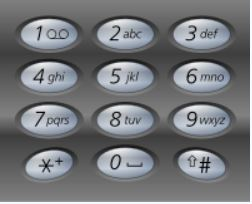

The digit 0 maps to 0 itself. The digit 1 maps to 1 itself.

NOTE: Make sure the returned strings are lexicographically sorted.

In [ ]:
def combinations(inp, num_map, index, ans):
    if index == len(inp):
        print(ans)
        return

    for i in range(len(num_map[inp[index]])):
        ans += num_map[inp[index]][i]
        combinations(inp, num_map, index+1, ans)
        ans = list(ans)
        ans.pop(len(ans)-1)
        ans = ''.join(ans)

num_map = {
			'0' : "0",
			'1' : "1",
			'2' : "abc",
			'3' : "def",
			'4' : "ghi",
			'5' : "jkl",
			'6' : "mno",
			'7' : "pqrs",
			'8' : "tuv",
			'9' : "wxyz"
		}
inp = '23'
combinations(inp, num_map, 0, '')

ad
ae
af
bd
be
bf
cd
ce
cf


# Kth Symbol - Easy
On the first row, we write a 0. Now in every subsequent row, we look at the previous row and replace each occurrence of 0 with 01, and each occurrence of 1 with 10.

Given row number A and index B, return the Bth indexed symbol in row A. (The values of B are 0-indexed.).

IP:
A = 3
B = 0

OP: 0

In [ ]:
from os import replace
def gen_pattern(row):
    if row == 1:
        return '0'
    elif row == 2:
        return '01'
    init = '01'
    for i in range(2,row):
        init = init.replace('0', '0#')
        init = init.replace('1', '10')
        init = init.replace('#', '1')
    return init

op = gen_pattern(4)
op

'01101001'

# Kth Symbol - Hard
Recursion

In [ ]:
# This approach has TLE error for large inputs
def gen_symbol(row_num, index):
    if row_num == 1 or index == 0:
        return 0
    no_of_chars_prev_row =  2 ** (row_num-2)
    if index > no_of_chars_prev_row :
        return 1-gen_symbol(row_num-1, index - no_of_chars_prev_row)
    else:
        return gen_symbol(row_num-1, index)

# Output
row_num = 4
index = 6
op = gen_symbol(row_num, index+1)
op


0

In [ ]:
# Approach 2
def gen_symbol(index):
    if index == 1:
        return 0
    if index % 2 == 0:
        return 1 - gen_symbol(index // 2)
    else:
        return gen_symbol(index//2+1)
# Output
row_num = 5
index = 13
op = gen_symbol(index+1)
op

1

ToDO
# Print All Maze Paths
You are given the dimensions of a rectangular board of size A x B. You need to print all the possible paths from top-left corner to bottom-right corner of the board.

You can only move down (denoted by 'D') or right (denoted by 'R') at any point in time.
Input 1 :
A = 3 , B = 2
Output 1 :
DDR DRD RDD

In [ ]:
x = [[1,2], [4,5], [3,6]]
y = x.copy()
y

[[1, 2], [4, 5], [3, 6]]

In [ ]:
x = [False] *5
x = [x]*3
x

[[False, False, False, False, False],
 [False, False, False, False, False],
 [False, False, False, False, False]]

#  Intersection of Linked Lists
Write a program to find the node at which the intersection of two singly linked lists, A and B, begins. For example, the following two linked lists:

```
A:      a1 → a2
                   ↘
                     c1 → c2 → c3
                   ↗
B:     b1 → b2 → b3
```

NOTE:
If the two linked lists have no intersection at all, return null.
The linked lists must retain their original structure after the function returns.
You may assume there are no cycles anywhere in the entire linked structure.
Your code should preferably run in O(n) time and use only O(1) memory.
The custom input to be given is different than the one explained in the examples. Please be careful.

Example Input

Input 1:

 A = [1, 2, 3, 4, 5]
 B = [6, 3, 4, 5]
Input 2:

 A = [1, 2, 3]
 B = [4, 5]


Example Output

Output 1:

 [3, 4, 5]
Output 2:

 []

In [ ]:
'''
Definition for singly-linked list
class ListNode:
   def __init__(self, val):
      self.val = val
      self.next = None
'''
class Solution:
    def getIntersectionNode(self, A, B):
        h1 = A
        h2 = B
        # count no. of node in first LL
        c1 = 0
        while(h1):
            c1 += 1
            h1 = h1.next

        # count no. of nodes in second LL
        c2 = 0
        while(h2):
            c2 += 1
            h2 = h2.next

        h1 = A
        h2 = B

        if c1 > c2:
            diff = c1-c2
            while(diff > 0):
                h1 = h1.next
                diff -= 1
        else:
            diff = c2 - c1
            while(diff > 0):
                h2 = h2.next
                diff -= 1


        while(h1 and h2):
            if h1 == h2:
                return h1
            h1 = h1.next
            h2 = h2.next

        return None


# Remove Loop from Linked List
Problem Description

You are using Google Maps to help you find your way around a new place. But, you get lost and end up walking in a circle. Google Maps has a way to keep track of where you've been with the help of special sensors.These sensors notice that you're walking in a loop, and now, Google wants to create a new feature to help you figure out exactly where you started going in circles.

Here's how we can describe the challenge in simpler terms: You have a Linked List A that shows each step of your journey, like a chain of events. Some of these steps have accidentally led you back to a place you've already been, making you walk in a loop. The goal is to find out the exact point where you first started walking in this loop, and then you want to break the loop by not going in the circle just before this point.

In [ ]:
class Solution:
    def solve(self, A):
        fast, slow = A, A

        while(True):
            fast = fast.next.next
            slow = slow.next

            if fast == slow:
                slow = A

                prev = None

                while fast != slow:
                    prev = fast
                    fast = fast.next
                    slow = slow.next
                break
        prev.next = None
        return A

# Sort Link List
IP: Head of the LL
OP: Head of the sorted LL

In [ ]:
def get_middle_node(head):
    if not head or not head.next:
        return head

    fast = head
    slow = head

    while(fast.next and fast.next.next):
        fast = fast.next.next
        slow = slow.next
    return slow

def merge_two_link_list(head1, head2):
    if not head1 and not head2:
        return None
    elif not head1:
        return head2
    elif not head2:
        return head1

    if head1.val <= head2.val:
        head = head1
        head1 = head1.next
    else:
        head = head2
        head2 = head2.next
    temp = head

    while(head1 and head2):
        if head1.val <= head2.val:
            temp.next = head1
            head1 = head1.next
        else:
            temp.next = head2
            head2 = head2.next
        temp = temp.next

    if not head1 and head2:
        temp.next = head2
    elif head1 and not head2:
        temp.next = head1
    return head

def sort_link_list(head):
    if not head or not head.next:
        return head
    mid = get_middle_node(head)
    head2 = mid.next
    mid.next = None
    # sorted link list first part
    sorted_p1 = sort_link_list(head)
    # sorted link list second part
    sorted_p2 = sort_link_list(head2)
    merged_ll_head = merge_two_link_list(sorted_p1, sorted_p2)
    return merged_ll_head

# function calls
list_ = [2, 3, 4, 8, 1, 5, 6, 7]
head = list_to_linked_list(list_)
sorted_head = sort_link_list(head)
op = linked_list_to_list(sorted_head)
op



[1, 2, 3, 4, 5, 6, 7, 8]

# Swap List Nodes in pairs
Given a linked list A, swap every two adjacent nodes and return its head.

NOTE: Your algorithm should use only constant space. You may not modify the values in the list; only nodes themselves can be changed.
IP: 1 -> 2 -> 3 -> 4
OP: 2 -> 1 -> 4 -> 3

In [ ]:
def swapPairs(A):
	if not A.next:
		return A
	node = A
	head = node.next

	prev = None
	while(node and node.next):
		h2 = node.next.next
		node.next.next = node
		if prev:
			prev.next = node.next
		node.next = h2
		prev = node
		node = node.next
	return head

# function calls
list_ = [1, 2, 3, 4, 5]
head = list_to_linked_list(list_)
op_head = swapPairs(head)
lst = linked_list_to_list(op_head)
lst

[2, 1, 4, 3, 5]

# Add Two Numbers as Lists
Topic: LinkList

You are given two linked lists, A and B, representing two non-negative numbers.

The digits are stored in reverse order, and each of their nodes contains a single digit.

Add the two numbers and return it as a linked list.

Input:
 A = [2, 4, 3]
 B = [5, 6, 4]

 Output:
 [7, 0, 8]

In [ ]:
class ListNode:
	def __init__(self, x):
		self.val = x
		self.next = None

# function calls
A = [9,9,9]
A = list_to_linked_list(A)

B = [1]
B = list_to_linked_list(B)


head = None
c = 0
while(A or B):
    if A:
        x = A.val
    else:
        x = 0
    if B:
        y = B.val
    else:
        y = 0
    sm = x + y + c
    n = sm % 10
    c = sm // 10
    curr_node = ListNode(n)
    print(f'curr_node: {curr_node.val}')
    if not head:
        head = curr_node
        prev_node = curr_node
    else:
        prev_node.next = curr_node
        prev_node = curr_node
    if A:
        A = A.next
    if B:
        B = B.next
if c != 0:
    node = ListNode(c)
    prev_node.next = node
lst = linked_list_to_list(head)
lst
# 9 9 9
# 1
# 0 0 2

curr_node: 0
curr_node: 0
curr_node: 0


[0, 0, 0, 1]

# Longest Palindromic List in a Link List
Given a linked list of integers. Find and return the length of the longest palindrome list that exists in that linked list.

IP 1: 2 -> 3 -> 3 -> 3
OP 1: 3

IP 2: 2 -> 1 -> 2 -> 1 ->  2 -> 2 -> 1 -> 3 -> 2 -> 2
OP 2: 5

In [ ]:
# Definition for singly-linked list.
# class ListNode:
#    def __init__(self, x):
#        self.val = x
#        self.next = None

class Solution:
    def solve(self, head):
            if not head:
                return 0

            ans = 0
            curr = head
            prev = None

            while curr:
                # Reverse the first part of the list up to the current node
                next_node = curr.next
                curr.next = prev

                # Check for EVEN length palindromes centered at 'curr'
                # Compare the reversed part (starting from 'curr') with the original second part (starting from 'next_node')
                p1 = curr
                p2 = next_node
                count_even = 0
                while p1 and p2 and p1.val == p2.val:
                    count_even += 1
                    p1 = p1.next
                    p2 = p2.next
                ans = max(ans, 2 * count_even )

                # Check for ODD length palindromes with center between 'prev' and 'curr'
                # Compare the reversed part (starting from 'prev') with the original second part (starting from 'next_node')
                p1 = prev
                p2 = next_node
                count_odd = 0
                while p1 and p2 and p1.val == p2.val:
                    count_odd += 1
                    p1 = p1.next
                    p2 = p2.next
                ans = max(ans, 2 * count_odd+1)

                # Move to the next node in the original list and update 'prev'
                prev = curr
                curr = next_node

            return ans

In [ ]:
list_ = [ 6, 6, 5, 5, 6, 4]
head = list_to_linked_list(list_)
ans = find_longest_palindrome(head)
print(f"The longest palindrome length for {list_} is: {ans}")

The longest palindrome length for [6, 6, 5, 5, 6, 4] is: 5


# Partition List
[Link List]

Given a linked list A and a value B, partition it such that all nodes less than B come before nodes greater than or equal to B.

You should preserve the original relative order of the nodes in each of the two partitions.

Input 1:
A = [1, 4, 3, 2, 5, 2]
B = 3

Output 1:
[1, 2, 2, 4, 3, 5]

In [ ]:
class ListNode:
	def __init__(self, x):
		self.val = x
		self.next = None

def partition( A, B):
    dummy_less = ListNode(0)
    dummy_greater = ListNode(0)
    less, greater = dummy_less, dummy_greater

    # Traverse the original list
    current = A
    while current:
        node = ListNode(current.val)
        if current.val < B:
            # Add to less list
            less.next = node
            # Update less pointer
            less = less.next
        else:
            # Add to greater list
            greater.next = node
            # Update greater pointer
            greater = greater.next
        current = current.next

    # Join the two lists
    less.next = dummy_greater.next
    # Return the head of the new list
    return dummy_less.next

# function call
# lst = [4, 1, 3, 2, 5, 2]
# lst = [1, 4, 3, 2, 5, 2]
lst = [1, 2, 3, 4, 5]
B = 5
head = list_to_linked_list(lst)
op_head = partition(head, B)
op = linked_list_to_list(op_head)
op



[1, 2, 3, 4, 5]

In [ ]:
# Without Using the Extra Space

class Solution:
	def partition(self, A, B):
        greater_than_B_found = False
        dummy = ListNode(0)
        dummy.next = A
        curr = A
        curr_small = dummy

        while(curr):
            if curr.val < B:
                if greater_than_B_found:
                    deleted = curr
                    curr = curr.next
                    prev.next = curr

                    curr_small_ka_next = curr_small.next
                    curr_small.next = deleted
                    deleted.next = curr_small_ka_next

                    curr_small = deleted
                else:
                    curr_small =curr
                    prev = curr
                    curr = curr.next
            else:
                if not greater_than_B_found:
                    greater_than_B_found = True
                prev = curr
                curr = curr.next

        return dummy.next


# LRU Cache
Design and implement a data structure for Least Recently Used (LRU) cache. It should support the following operations: get and set.

get(key) - Get the value (will always be positive) of the key if the key exists in the cache, otherwise return -1.
set(key, value) - Set or insert the value if the key is not already present. When the cache reaches its capacity, it should invalidate the least recently used item before inserting the new item.
The LRUCache will be initialized with an integer corresponding to its capacity. Capacity indicates the maximum number of unique keys it can hold at a time.

Definition of "least recently used" : An access to an item is defined as a get or a set operation of the item. "Least recently used" item is the one with the oldest access time.

In [ ]:
from typing_extensions import Counter
class dbl_ll:
    def __init__(self, key):
        self.val = key
        self.next = None
        self.prev = None

class LRUCache:
    dct = dict()
    counter = 0
    head, tail = None, None

    def __init__(self, capacity):
        self.capacity = capacity

    def remove(self, key= None):
        if not key:
            key = LRUCache.head.val
        address = LRUCache.dct[key]['address']
        if address == LRUCache.head:
            if LRUCache.head.next:
                LRUCache.head = LRUCache.head.next
                LRUCache.head.prev.next = None
                LRUCache.head.prev = None
            LRUCache.head = LRUCache.head.next
        elif address == LRUCache.tail:
            if LRUCache.tail.prev:
                LRUCache.tail = LRUCache.tail.prev
                LRUCache.tail.next.prev = None
                LRUCache.tail.next = None
            LRUCache.tail = LRUCache.tail.prev
        else:
            if address.prev:
                address.prev.next = address.next
            if address.next:
                address.next.prev = address.prev
        # remove from dictionary
        LRUCache.dct.pop(key)
        LRUCache.counter -= 1

    def get(self, key):
        if key in LRUCache.dct.keys():
            address = LRUCache.dct[key]
            if address == LRUCache.tail:
                return LRUCache.dct[key]['val']
            else:
                val = LRUCache.dct[key]['val']
                self.remove(key)
                self.set(key, val)
                return LRUCache.dct[key]['val']
        else:
            return -1

    def set(self, key, value):
        if LRUCache.counter == self.capacity:
            if key in LRUCache.dct.keys():
                self.remove(key)
            else:
                self.remove()

        node = dbl_ll(key)
        LRUCache.dct[key] = {
            "val" : value,
            "address" : node
        }

        if LRUCache.tail:
            node.prev = LRUCache.tail
            LRUCache.tail.next = node
            LRUCache.tail = node
        else:
            LRUCache.head, LRUCache.tail = node, node

        LRUCache.counter += 1

    def print_dll(self):
        print(f'capacity = {self.capacity}, Counter = {LRUCache.counter}')
        tmp = LRUCache.head
        while(tmp):
            print(f'{tmp.val}', end=' -> ' )
            tmp = tmp.next
        print()

# call
obj = LRUCache(1)

# 6 1 S 2 1 S 2 2 G 2 S 1 1 S 4 1 G 2


# obj = LRUCache(1)
# obj.set(2,1)
# obj.print_dll()

# obj.set(2,2)
# obj.print_dll()

# obj.get(2)
# obj.print_dll()

# obj.set(1,1)
# obj.print_dll()

# obj.set(4,1)
# obj.print_dll()

# op = obj.get(2)
# obj.print_dll()
# op

# 7 2 G 2 S 2 6 G 1 S 1 5 S 1 2 G 1 G 2
obj = LRUCache(2)

op = obj.get(2)
print('1st get: ',op)

obj.set(2,6)

op = obj.get(1)
print('2nd get: ',op)

obj.set(1,5)
obj.print_dll()

obj.set(1,2)
obj.print_dll()

op = obj.get(1)
print('3rd get: ',op)

op = obj.get(2)
print('4th get: ',op)

1st get:  -1
2nd get:  -1
capacity = 2, Counter = 2
2 -> 1 -> 
capacity = 2, Counter = 2
1 -> 
3rd get:  2
4th get:  6


In [ ]:
from typing_extensions import Counter
class dbl_ll:
    def __init__(self, key, val):
        self.key = key
        self.val = val
        self.next = None
        self.prev = None

class LRUCache:
    def __init__(self, capacity):
        self.capacity = capacity
        self.dct = {}
        # Dummy head and tail nodes to simplify insertion and deletion
        self.head = dbl_ll(0, 0)
        self.tail = dbl_ll(0, 0)
        self.head.next = self.tail
        self.tail.prev = self.head

    # Add a node to the end (most recently used)
    def _add_node(self, node):
        node.prev = self.tail.prev
        node.next = self.tail
        self.tail.prev.next = node
        self.tail.prev = node

    # Remove a node from the linked list
    def _remove_node(self, node):
        prev_node = node.prev
        next_node = node.next
        prev_node.next = next_node
        next_node.prev = prev_node

    # Move an existing node to the end (most recently used)
    def _move_to_end(self, node):
        self._remove_node(node)
        self._add_node(node)

    def get(self, key):
        if key in self.dct:
            node = self.dct[key]
            self._move_to_end(node)
            return node.val
        else:
            return -1

    def set(self, key, value):
        if key in self.dct:
            # If key exists, update the value and move to end
            node = self.dct[key]
            node.val = value
            self._move_to_end(node)
        else:
            # If key does not exist, add new node
            if len(self.dct) >= self.capacity:
                # Remove least recently used (head's next)
                lru_node = self.head.next
                self._remove_node(lru_node)
                del self.dct[lru_node.key]

            new_node = dbl_ll(key, value)
            self.dct[key] = new_node
            self._add_node(new_node)

    def print_dll(self):
        print(f'capacity = {self.capacity}, size = {len(self.dct)}')
        tmp = self.head.next
        while tmp and tmp != self.tail:
            print(f'({tmp.key}, {tmp.val})', end=' -> ' )
            tmp = tmp.next
        print()

# call
# 6 1 S 2 1 S 2 2 G 2 S 1 1 S 4 1 G 2
obj = LRUCache(1)
obj.set(2,1)
obj.print_dll()
obj.set(2,2)
obj.print_dll()
op = obj.get(2)
print('1st get: ',op)
obj.print_dll()
obj.set(1,1)
obj.print_dll()
obj.set(4,1)
obj.print_dll()
op = obj.get(2)
print('2nd get: ',op)
obj.print_dll()


# 7 2 G 2 S 2 6 G 1 S 1 5 S 1 2 G 1 G 2
# obj = LRUCache(2)
# op = obj.get(2)
# print('1st get: ',op)
# obj.set(2,6)
# op = obj.get(1)
# print('2nd get: ',op)
# obj.set(1,5)
# obj.print_dll()
# obj.set(1,2)
# obj.print_dll()
# op = obj.get(1)
# print('3rd get: ',op)
# op = obj.get(2)
# print('4th get: ',op)

capacity = 1, size = 1
(2, 1) -> 
capacity = 1, size = 1
(2, 2) -> 
1st get:  2
capacity = 1, size = 1
(2, 2) -> 
capacity = 1, size = 1
(1, 1) -> 
capacity = 1, size = 1
(4, 1) -> 
2nd get:  -1
capacity = 1, size = 1
(4, 1) -> 


# DEL keyword

In [ ]:
dct = dict()
dct['a'] = 1
dct['b'] = 2

dct
del dct['b']
dct

{'a': 1}

**Connect Ropes**
HEAP

In [ ]:
class Solution:
    def swap(self, heap, parent, child):
        tmp = heap[child]
        heap[child] = heap[parent]
        heap[parent] = tmp

    def upheapify(self, heap):
        _len = len(heap)
        child = _len-1
        parent = (child-1)//2

        while(parent >= 0 and heap[parent] > heap[child]):
            self.swap(heap, parent, child)
            child = parent
            parent = (child-1) // 2

    def downheapify(self, heap):
        _len = len(heap)
        parent = 0
        lc = 2 * parent + 1
        rc = 2 * parent + 2

        while(rc < _len):
            if heap[parent] <= heap[lc] and heap[parent] <= heap[rc]:
                return
            if heap[rc] < heap[lc]:
                self.swap(heap, parent, rc)
                parent = rc
            else:
                self.swap(heap, parent, lc)
                parent = lc
            lc = 2 * parent + 1
            rc = 2 * parent + 2

        if lc < _len and heap[parent] > heap[lc]:
            self.swap(heap, parent, lc)

    def extract(self, heap):
        if len(heap) == 1:
            return heap[0]
        self.swap(heap, 0, len(heap)-1)
        _min = heap.pop()
        self.downheapify(heap)
        return _min


    def solve(self, A):
        if len(A) == 1:
            return A[0]
        elif len(A) == 2:
            return A[0]+A[1]
        heap = []
        heap.append(A[0])
        for i in range(1, len(A),1):
            heap.append(A[i])
            self.upheapify(heap)
        print('heap: ', heap)
        _min1 = self.extract(heap)
        _min2 = self.extract(heap)
        cost = _min1 + _min2
        print('Cost: ', cost)
        heap.append(cost)
        self.upheapify(heap)

        while(len(heap) > 1):
            _min = self.extract(heap)
            cost += _min
            heap.append(cost)
            self.upheapify(heap)
        return cost

In [ ]:
ip = [16,7,3,5,9,8,6,15]
obj = Solution()
cost = obj.solve(ip)
cost

6, 15, 9, 8, 7, 16, 8



# Morris Inorder Traversal
Given a binary tree, return the inorder traversal of its nodes' values.

NOTE: Using recursion and stack are not allowed.

In [ ]:
class Solution:
    def solve(self, A):
        op = []
        curr = A

        while(curr):
            if not curr.left:
                op.append(curr.val)
                curr = curr.right
            else:
                temp = curr.left
                while(temp.right and temp.right != curr):
                    temp = temp.right
                if not temp.right:
                    temp.right = curr
                    curr = curr.left
                else:
                    op.append(curr.val)
                    temp.right = None
                    curr = curr.right
        return op

# function call
lvl_ordr_traversal = [6, 9, 4, -1, -1, 8, -1, -1, 3, -1, -1]
root = get_tree(lvl_ordr_traversal)
obj = Solution()
op = obj.solve(root)
op


[9, 6, 8, 3, 4]

# LCA in BST
Given a Binary Search Tree A. Also given are two nodes B and C. Find the lowest common ancestor of the two nodes.


Note 1 :- It is guaranteed that the nodes B and C exist.

Note 2 :- The LCA of B and C in A is the shared ancestor of B and C that is located farthest from the root.

In [ ]:
class Solution:
    def find_lca(self, root, B, C):
        if B == root.val or C == root.val or (B < root.val and C > root.val) or (B > root.val and C < root.val):
            return root.val
        elif B < root.val and C < root.val:
            return self.find_lca(root.left, B, C)
        else:
            return self.find_lca(root.right, B, C)

    def solve(self, A, B, C):
        return self.find_lca(A, B, C)


# Least Common Ancestor
Find the lowest common ancestor in an unordered binary tree A, given two values, B and C, in the tree.


Lowest common ancestor: the lowest common ancestor (LCA) of two nodes and w in a tree or directed acyclic graph (DAG) is the lowest (i.e., deepest) node that has both v and w as descendants.

In [ ]:
class Solution:
    def search(self, root, key):
        if not root:
            return False
        if root.val == key:
            return True
        l = self.search(root.left, key)
        r = self.search(root.right, key)
        return l or r

    def find_lca(self, root, B, C):
        if not root:
            return None
        if root.val == B or root.val == C:
            return root.val

        l = self.find_lca(root.left, B, C)
        r = self.find_lca(root.right, B, C )
        if l and r:
            return root.val
        elif l:
            return l
        else:
            return r

    def lca(self, A, B, C):
        if self.search(A, B) and self.search(A, C):
            return self.find_lca(A, B, C)
        else:
            return -1

# Distance between Nodes of BST
Given a binary search tree.
Return the distance between two nodes with given two keys B and C. It may be assumed that both keys exist in BST.

NOTE: Distance between two nodes is number of edges between them. Distance between Nodes of BST


         5
       /   \
      2     8
     / \   / \
    1   4 6   11
 B = 2
 C = 11

 op = 3

In [ ]:
# Definition for a  binary tree node
# class TreeNode:
#    def __init__(self, x):
#        self.val = x
#        self.left = None
#        self.right = None

class Solution:
    def get_dist(self, root, key):
        if not root:
            return -1
        if root.val == key:
            return 0
        l = self.get_dist(root.left, key)
        r = self.get_dist(root.right, key)
        if l > -1:
            return l+1
        elif r > -1:
            return r+1
        else:
            return -1

    def find_lca(self, root, B, C):
        if not root:
            return None
        if  root.val == B or root.val == C:
            return root
        l = self.find_lca(root.left, B, C)
        r = self.find_lca(root.right, B, C)

        if l and r:
            return root
        elif l:
            return l
        else:
            return r

    def solve(self, A, B, C):
        lca = self.find_lca(A, B, C)

        if lca.val == B :
            dist = self.get_dist(lca, C)
            return dist
        elif lca.val == C:
            dist = self.get_dist(lca, B)
            return dist

        return self.get_dist(lca, B) + self.get_dist(lca, C)


# Next Pointer Binary Tree
Given a binary tree,

Populate each next pointer to point to its next right node. If there is no next right node, the next pointer should be set to NULL.

Initially, all next pointers are set to NULL.

Assume perfect binary tree.

IP:

         1
       /  \
      2    5
     / \  / \
    3  4  6  7

OP:

         1 -> NULL
       /  \
      2 -> 5 -> NULL
     / \  / \
    3->4->6->7 -> NULL


In [ ]:
class Solution:
    def connect(self, root):
        curr = root
        tmp = None
        while(curr.left):
            tmp = curr
            while(curr):
                curr.left.next = curr.right
                if curr.next:
                    curr.right.next = curr.next.left
                curr = curr.next
            curr = tmp.left
        return root



# Diameter of binary tree
Given a Binary Tree A consisting of N integer nodes, you need to find the diameter of the tree.

The diameter of a tree is the number of edges on the longest path between two nodes in the tree.
IP:

           1
         /   \
        2     3
       / \
      4   5

OP: 3

In [ ]:
class Solution:
    def get_diameter(self, root):
        if not root:
            return -1
        l = self.get_diameter(root.left)
        r = self.get_diameter(root.right)
        self.ans = max(self.ans, l+r+2)
        return max(l,r)+1

    def solve(self, A):
        self.ans = -1
        self.get_diameter(A)
        return self.ans

# Vertical Order traversal
Given a binary tree, return a 2-D array with vertical order traversal of it. Go through the example and image for more details.

IP:

            6
          /   \
         3     7
        / \   / \
       2   5 8    9
      / \
     1   4
          \
          10

IP: [6 3 7 2 5 8 9 1 4 -1 -1 -1 -1 -1 -1 -1 -1 -1 10 -1 -1]

OP:[1 ] [2 ] [3 4 ] [6 5 8 10 ] [7 ] [9 ]

https://s3.ap-south-1.amazonaws.com/scaler-production-domestic/public_assets/assets/000/000/071/original/378.jpeg?1614507246

In [ ]:
class Solution:
	def verticalOrderTraversal(self, A):
        dct = dict()
        min_hor_dst = float('inf')
        max_hor_dst = float('-inf')
        queue = [[A,0]]

        while(queue):
            n = len(queue)
            for i in range(n):
                val = queue.pop(0)
                root = val[0]
                hor_dst = val[1]
                if not dct.get(hor_dst):
                    dct[hor_dst] = []
                dct[hor_dst].append(root.val)
                min_hor_dst = min(min_hor_dst, hor_dst)
                max_hor_dst = max(max_hor_dst, hor_dst)

                if root.left:
                    queue.append([root.left, hor_dst-1])
                if root.right:
                    queue.append([root.right, hor_dst+1])

        op = []

        for i in range(min_hor_dst, max_hor_dst+1):
            op.append(dct[i])
        return op



# Longest Consecutive Sequence
Given an unsorted integer array A of size N.


Find the length of the longest set of consecutive elements from array A.

IP: [100, 4, 200, 1, 3, 2]
OP: 4

Explantion: [4,1,3,2]

In [ ]:
class Solution:
	def longestConsecutive(self, A):
        _set = { e for e in A}
        ans = -1
        for i in range(len(A)):
            x = A[i]
            # check if the prev no is present, if yes, then the consecutive sequence from the current no will not be maximum
            if x-1 not in _set:
                cnt = 0

                while(x in _set):
                    cnt += 1
                    x += 1
                ans = max(ans, cnt)
        return ans


# Count Subarrays
Misha likes finding all Subarrays of an Array. Now she gives you an array A of N elements and told you to find the number of subarrays of A, that have unique elements.

Since the number of subarrays could be large, return value % 109 +7.
IP: [2, 1, 2]
OP: 5

In [ ]:
class Solution:
    def solve(self, A):
        l, r = 0, 0
        ans = 0
        mp = {}  # This will store the last index of each element
        n = len(A)

        while r < n:
            if A[r] in mp and mp[A[r]] >= l:
                # If A[r] has been seen before and its last occurrence is >= l,
                # we need to move l to the next index after the last occurrence of A[r]
                # Ex IP: [1,2,3,2,1]
                l = mp[A[r]] + 1

            # Update the last occurrence of A[r]
            mp[A[r]] = r

            # Add the number of subarrays that end at r and contain unique elements
            ans = (ans + r - l + 1) % (10**9 + 7)

            # Move r to the next element
            r += 1

        return ans

# Backtracking - Generate all Parentheses II

Given an integer A pairs of parentheses, write a function to generate all combinations of well-formed parentheses of length 2*A.

IP: 3

OP: `[ "((()))", "(()())", "(())()", "()(())", "()()()" ]`

In [ ]:
class Solution:
    def add_par(self, _str, co, cc, A):
        if len(_str) == 2*A:
            self.op.append(_str)
            return

        if co < A:
            self.add_par(_str+'(', co+1, cc, A)
        if cc < co:
            self.add_par(_str+')', co, cc+1, A)


	def generateParenthesis(self, A):
        self.op = []
        self.add_par('',0,0,A)
        return self.op

((()))
(()())
(())()
()(())
()()()


# Backtracking - Generate Subsets


In [ ]:
def gen_subsets(arr, i, _set):
    if i == len(arr):
        print(_set)
        return
    # add to set
    _set.append(arr[i])
    gen_subsets(arr, i+1, _set )
    _set.pop(len(_set)-1)
    # not add to set
    gen_subsets(arr, i+1, _set )

#call
_set = []
arr = [1,2,3]
gen_subsets(arr,0,_set)

[1, 2, 3]
[1, 2]
[1, 3]
[1]
[2, 3]
[2]
[3]
[]


In [ ]:
# Backtracking: Permutations

In [ ]:
def permute(A, used, op):
    if len(op) == len(A):
        print(op)
        return

    for i in range(len(A)):
        if not used[i]:
            used[i] = True
            permute(A, used, op+A[i])
            used[i] = False
# call
A = 'ABC'
used = [False]* len(A)
op = ''

permute(A, used, op)

ABC
ACB
BAC
BCA
CAB
CBA


# Children and Rides
In an amusement park, there are rides being constructed for N children. Each ride has a maximum capacity limit of B for the total weight of the children on board.

You are given an array of weights of children, where A[i] is the weight of the i-th child, and an infinite number of rides. Each ride can carry at most two children at the same time, provided the sum of their weights is at most the ride's capacity limit.

Find the minimum number of rides to accommodate all the children.

Input 1:
A = [1, 2, 3]
B = 4

Input 2:
A = [3, 2, 2, 0, 1]
B = 4

In [ ]:
class Solution:
    def solve(self, A, B):
        A.sort()
        n = len(A)

        l,r = 0, n-1
        ans = 0

        while(l <= r):
            if A[l]+A[r] <= B:
                ans += 1
                l += 1
                r -= 1
            else:
                ans += 1
                r -= 1
        return ans

# call
A = [3, 2, 2, 0, 1]
B = 4
obj = Solution()
op = obj.solve(A,B)
op

3

# Permutations
Given an integer array A of size N denoting collection of numbers , return all possible permutations.

NOTE:

No two entries in the permutation sequence should be the same.
For the purpose of this problem, assume that all the numbers in the collection are unique.
Return the answer in any order.

IP:
A = [1, 2, 3]

OP:
[ [1, 2, 3]
  [1, 3, 2]
  [2, 1, 3]
  [2, 3, 1]
  [3, 1, 2]
  [3, 2, 1] ]

In [ ]:
def permute(A, U, op):
    if len(op) == 3:
        print(op)
    for i in range(3):
        if not U[i]:
            op.append(A[i])
            U[i] = True
            permute(A, U, op)
            op.pop(len(op)-1)
            U[i] = False

# call
A = [1,2,3]
U = [False, False, False]
permute(A, U, [])

[1, 2, 3]
[1, 3, 2]
[2, 1, 3]
[2, 3, 1]
[3, 1, 2]
[3, 2, 1]


# Number of Digit one
Given an integer A, find and return the total number of digit 1 appearing in all non-negative integers less than or equal to A.

IP:
A = 11

OP:
4

In [ ]:
def get_digit_one_cnt(N):
    ans = 0
    K = N
    i = 1
    while(K):
        dividend = N // (i*10)
        remainder = N % (i*10)

        ans += dividend * i

        # Between 1 to 100 there are 10 Ones (10 to 19) at 2nds place. if N = 15, then 15 should be subtracted by (10-1) i.e 9 to 6 ones at 2nds place i.e 10 to 15.
        if remainder - (i-1) > 0:
            # In N=29 then Remainder will be 29 and 29-9 = 20 but max 1 at 2nds place is 10, so limiting it to 10 even the remainder is larger than 10.
            ans += min(remainder - (i-1), i)

        K = K // 10
        i = i*10

    return ans

# call
ans = get_digit_one_cnt(20)
ans

12

# Consecutive Numbers Sum

`TO BE UNDERSTOOD`

Given a positive integer A.

Return the number of ways it can be written as a sum of consecutive positive integers.

IP: A = 15

OP: 4

The 4 ways are:
 => [15]
 => [7, 8]
 => [4, 5, 6]
 => [1, 2, 3, 4, 5]

In [ ]:
# ToDo
class Solution:
    def solve(self, A):
        cnt = 0
        K = 1
        while (K * (K + 1) // 2 <= A):
            start_term = (2 * A - K * (K - 1)) // (2 * K)
            if (2 * A - K * (K - 1)) % (2 * K) == 0 and start_term > 0:
                cnt += 1
            K += 1
        return cnt


# Count of divisors
Given an array of integers A, find and return the count of divisors of each element of the array.

NOTE: The order of the resultant array should be the same as the input array.

IP:

A = [8, 9, 10]

OP:

[4, 3, 4]

In [ ]:
class Solution:
    def solve(self, A):
        n = max(A)
        MD = []

        i = 0
        while(i <= n):
            MD.append(i)
            i+=1

        i = 2
        while(i * i <= n ):
            if MD[i] == i:
                for j in range(i*i, n+1, i):
                    if MD[j] == j:
                        MD[j] = i
            i += 1

        ans = []
        for x in A:
            md = MD[x]
            pw =1
            while(x != 1):
                cnt = 1
                while(x % md == 0):
                    cnt += 1
                    x = x // md
                pw *= cnt
                md = MD[x]
            ans.append(pw)
        return ans

# Pairs with given sum II

Given a sorted array of integers (not necessarily distinct) A and an integer B, find and return how many pair of integers ( A[i], A[j] ) such that i != j have sum equal to B.

Since the number of such pairs can be very large, return number of such pairs modulo (109 + 7).

IP:

A = [1, 5, 7, 10]
B = 8

OP:

1

In [ ]:
class Solution:
    def solve(self, A, B):
        i,j = 0, len(A)-1
        cnt = 0
        while(i < j):
            sm = A[i]+A[j]

            if sm == B:
                if A[i] == A[j]:
                    n= j-i+1
                    cnt += (n*(n-1)) // 2
                    break

                cnti = 0
                x = i
                while(x < j):
                    if A[x] == A[i]:
                        cnti += 1
                    else:
                        break
                    x += 1

                cntj = 0
                x = j
                while(x > i):
                    if A[x] == A[j]:
                        cntj += 1
                    else:
                        break
                    x -= 1

                cnt += cnti * cntj
                i += cnti
                j -= cntj

            elif sm < B:
                i += 1
            else:
                j -= 1

        return cnt % (10**9+7)

# 3 Sum
Given an array A of N integers, find three integers in A such that the sum is closest to a given number B. Return the sum of those three integers.

Assume that there will only be one solution.

IP:

A = [-1, 2, 1, -4]
B = 1

OP:

2

Explanation :

 The sum that is closest to the target is 2. (-1 + 2 + 1 = 2)

In [ ]:
class Solution:
	def threeSumClosest(self, A, B):
		n = len(A)
		A.sort()
		i,j,k = 0,1,n-1
		diff = float('inf')
		ans = sum(A)
		while(i < n-2):
			while(j < k):
				sm = A[i]+A[j]+A[k]
				if abs(sm-B) < diff:
					ans = sm
					diff = abs(sm-B)
				if sm > B:
					k -= 1
				else:
					j += 1
			i = i+1
			j = i+1
			k = n-1
		return ans


# Lucky Numbers
A lucky number is a number that has exactly 2 distinct prime divisors.

You are given a number A, and you need to determine the count of lucky numbers between the range 1 to A (both inclusive).

IP:

A = 12

OP:

3

In [ ]:
class Solution:

    def solve(self, A):
        SOE = []
        i = 0
        while(i <= A):
            SOE.append(i)
            i += 1

        i = 2

        while(i*i <= A):
            j = i*i
            while(j <= A):
                if SOE[j] == j:
                    SOE[j] = i
                j += i
            i += 1

        ans = 0
        for e in range(2, A+1):
            cnt = 0
            min_div = SOE[e]
            while(e!= 1):
                cnt += 1
                while(e % min_div == 0):
                    e = e // min_div
                min_div = SOE[e]
            if cnt == 2:
                ans += 1
        return ans






# Container With Most Water

Given N non-negative integers A[0], A[1], ..., A[N-1] , where each represents a point at coordinate (i, A[i]).

N vertical lines are drawn such that the two endpoints of line i is at (i, A[i]) and (i, 0).

Find two lines, which together with x-axis forms a container, such that the container contains the most water. You need to return this maximum area.

Note: You may not slant the container. It is guaranteed that the answer will fit in integer limits.

IP:
A = [1, 5, 4, 3]

OP:
6

Explanation :

5 and 3 are distance 2 apart. So size of the base = 2. Height of container = min(5, 3) = 3.
So total area = 3 * 2 = 6

In [ ]:
class Solution:
	def maxArea(self, A):
        i,j = 0, len(A)-1
        area = 0
        while(i<j):
            length = j-i
            breadth = min(A[i],A[j])
            area = max(area, length * breadth)
            if A[i] < A[j]:
                i += 1
            else:
                j -= 1
        return area

# Sorted Permutation Rank
Given a string A. Find the rank of the string amongst its permutations sorted lexicographically.
Assume that no characters are repeated.

Note: The answer might not fit in an integer, so return your answer % 1000003

IP: 'BCA'
OP: 4

In [ ]:
class Solution:
    def get_fact(self, n):
        if n == 0 or n== 1:
            return 1
        else:
            return n * self.get_fact(n-1)

	def findRank(self, A):
        n = len(A)
        ans = 0
        for i in range(n):
            cnt_smaller = 0
            for j in range(i+1, n):
                if A[j] < A[i]:
                    cnt_smaller += 1
            ans += cnt_smaller * self.get_fact(n-i-1)
            # print(A[i], ans)
        return (ans+1) % (1000003)

# Subarray with given sum
Given an array of positive integers A and an integer B, find and return first continuous subarray which adds to B.

If the answer does not exist return an array with a single integer "-1".

First sub-array means the sub-array for which starting index in minimum.

Input :

 A = [1, 2, 3, 4, 5]
 B = 5

 OP: [2,3]

In [ ]:
class Solution:
    def solve(self, A, B):
        X = A.copy() #Note
        dic = dict()
        dic[0] = 0 #Note
        for i in range(len(A)):
            if i == 0:
                if A[i] == B:
                    return [A[i]]
                else:
                    dic[A[i]] = i
            else:
                A[i] += A[i-1]
                diff = A[i]-B

                if diff in dic:
                    if diff == 0: #Note
                        return X[:i+1]
                    else:
                        return X[dic[diff]+1:i+1]
                else:
                    dic[A[i]] = i
        return [-1]

# Array 3 Pointers

You are given 3 sorted arrays A, B and C.

Find i, j, k such that : max(abs(A[i] - B[j]), abs(B[j] - C[k]), abs(C[k] - A[i])) is minimized.

Return the minimum max(abs(A[i] - B[j]), abs(B[j] - C[k]), abs(C[k] - A[i])

IP:

 A = [1, 4, 10]
 B = [2, 15, 20]
 C = [10, 12]

OP:

5

Explanation:

 With 10 from A, 15 from B and 10 from C.

In [ ]:
class Solution:
	def minimize(self, A, B, C):
        i,j,k = 0,0,0
        ans = float('infinity')
        while(i < len(A) and j < len(B) and k < len(C)):
            diff1 = abs(A[i]-B[j])
            diff2 = abs(B[j]-C[k])
            diff3 = abs(C[k]-A[i])

            curr_max = max(diff1, diff2, diff3)
            ans = min(ans, curr_max)

            current_min = min(A[i], B[j], C[k])
            if current_min == A[i]:
                i += 1
            elif current_min == B[j]:
                j += 1
            else:
                k += 1
        return ans


# Max Continuous Series of 1s

Given a binary array A, find the maximum sequence of continuous 1's that can be formed by replacing at-most B zeroes.

For this problem, return the indices of maximum continuous series of 1s in order.

If there are multiple possible solutions, return the sequence which has the minimum start index.

IP 1:

 A = [1, 1, 0, 1, 1, 0, 0, 1, 1, 1]
 B = 1

IP 2:

 A = [1, 0, 0, 0, 1, 0, 1]
 B = 2

Output 1:

 [0, 1, 2, 3, 4]
Output 2:

 [3, 4, 5, 6]

In [ ]:
class Solution:
	def maxone(self, A, B):
        l,r,c = 0,0,0
        n = len(A)
        max_len = -1
        R,L = 0,0

        while(r < n):
            if A[r] == 0:
                c += 1
            if c > B:
                # Keep shrinking window until valid
                if A[l] == 0:
                    c -= 1
                l += 1
            # Update max_len if current window is large
            if r-l+1 > max_len:
                max_len = r - l + 1
                L = l
                R = r + 1
            r += 1
        return [i for i in range(L, R)]

# Pairs with Given Difference
Given an one-dimensional integer array A of size N and an integer B.

Count all distinct pairs with difference equal to B.

Here a pair is defined as an integer pair (x, y), where x and y are both numbers in the array and their absolute difference is B.

IP1:

 A = [1, 5, 3, 4, 2]
 B = 3

IP2:

 A = [8, 12, 16, 4, 0, 20]
 B = 4

IP3:

 A = [1, 1, 1, 2, 2]
 B = 0

OP 1: 2
OP 2: 5
OP 3: 2

In [ ]:
class Solution:
    def solve(self, A, B):
        i,j = 0,1
        cnt = 0
        n = len(A)
        A.sort()
        while(j < n):
            diff = abs(A[j]-A[i])
            if diff == B:
                cnt += 1
                x = i
                while(i < j and A[i] == A[x]):
                    i += 1
                y = j
                while(j < n and A[j] == A[y]):
                    j += 1

            elif diff < B:
                j += 1
            else:
                i += 1
                if i == j:
                    j += 1

        return cnt

# Closest pair from sorted arrays
Given two sorted arrays of distinct integers, A and B, and an integer C, find and return the pair whose sum is closest to C and the pair has one element from each array.

More formally, find A[i] and B[j] such that abs((A[i] + B[j]) - C) has minimum value.

If there are multiple solutions find the one with minimum i and even if there are multiple values of j for the same i then return the one with minimum j.

Return an array with two elements {A[i], B[j]}.

**Problem Constraints**

1 <= length of both the arrays <= 105

1 <= A[i], B[i] <= 109

1 <= C <= 109

Example Input

Input 1:

 A = [1, 2, 3, 4, 5]
 B = [2, 4, 6, 8]
 C = 9
Input 2:

 A = [5, 10, 20]
 B = [1, 2, 30]
 C = 13

 Example Output

Output 1:

 [1, 8]
Output 2:

 [10, 2]

In [ ]:
class Solution:
    def solve(self, A, B, C):
        i,j = 0, len(B)-1
        mi, mj = len(A), len(B)
        diff = float('inf')
        op = [-1,-1]
        while( i < len(A) and j >= 0):
            sm = A[i]+B[j]
            curr_diff = abs(sm - C)

            if curr_diff <  diff:
                op[0] = A[i]
                op[1] = B[j]
                diff = curr_diff
                mi = i
            elif curr_diff == diff:
                if i == mi:
                    op[1] = B[j]

            if sm > C:
                j -= 1
            else:
                i += 1
        return op


# Number Line Confusion. [TO BE UNDERSTOOD]

**Problem Description**

Rick and Morty are planning a new adventure using a number line.

Morty selects two points, x and y,
*   forming Morty's interval: [min(|x|, |y|), max(|x|, |y|)

Rick then uses Morty's selected values(x, y) to calculate the points |x - y| and |x + y|,
*   forming Rick's interval: [min(|x - y|, |x + y|), max|x - y|, |x + y|)]


Given an array **A** of N distinct integers, find the number of unordered pairs (x,y) such that Morty's interval is **fully contained** within Rick's interval.

Note:
*   |x| denotes the absolute value of x.
*   An unordered pair means that the pair (x, y) is considered the same as (y, x).

**Problem Constraints**

1 <= N<= 10^5

-10^9 <= A; <= 10^9

All values in the array A are pairwise distinct.


**Input Format**

The first argument is the integer array A.

**Output Format**

Return a single integer denoting the number of unordered pairs.

Example Input

Input 1:

A = [-3, 5, -7]

Input 2:

A = [3, 6]

**Example Output**

Output 1:

2

Output 2:

1

**Example Explanation**

Explanation 1:

A = [-3, 5, -7]

For x= -3 and y = 5:
Morty's interval: [min(|-3|, |5|), max (|-3|, |5| )] = 3, 5

Rick's interval: [min(|-3 - 5|, |-3 + 5|), max (|-3 - 5|, |-3 + 5|)] = 2, 8

Morty's interval [3, 5] is fully contained within Rick's interval I2, 81, so this pair is valid.


For x = -3 and y = -7:

Morty's interval: [3, 7]
Rick's interval: [min(|-3 - (-7) |, |-3 + (-7) |), max (|-3 - (-7) |, |-3 + (-7) |)] = [4, 10]

Morty's interval [3, 7] is not fully contained within Rick's interval [4, 10], so this pair is not valid.

For x = 5 and y = -7:

Morty's interval: [5, 7]

Rick's interval: [min(|5 - (-7)|, |5 + (-7) |), max(|5 - (-7)|, |5 + (-7)|) = [2, 12]

Morty's interval [5, 7] is fully contained within Rick's interval [2, 12], so this pair is valid.

In total, there are 2 valid pairs: (-3, 5) and (5, -7) .

Explanation 2:

Morty's interval [3, 6] is fully contained within Rick's interval [3, 9], so this pair is valid.

In [ ]:
# A = [-3, 5, -7]
A = [ 2, 1, -7, 5, 8, -9, -8, -3, -6, 10 ]
abs_A = [abs(x) for x in A]
abs_A.sort()
left = 0
count = 0
for right in range(len(abs_A)):
    # For the current abs_A[right], find how many abs_A[left] (where left < right)
    # satisfy abs_A[right] <= 2 * abs_A[left]
    while left < right and abs_A[right] > 2 * abs_A[left]:
        left += 1
    # Now, for the current abs_A[right], all elements from index 'left' up to 'right - 1'
    # satisfy the condition. The number of such elements is (right - 1) - left + 1 = right - left.
    # We only consider pairs where left < right, so we add right - left to the count.
    count += (right - left)

print(count)

25


# Generate Subsets
Given a set of distinct integers A, return all possible subsets that can be formed from the elements of array A.

In [ ]:
class Solution:
    def generate_subsequence(self, A, cnt, seq):
        if cnt == len(A):
            self.ans.append(seq.copy())
            return
        # Add the elsement
        seq.append(A[cnt])
        self.generate_subsequence(A, cnt+1, seq)

        # remove the last added element
        seq.pop(len(seq)-1)

        # Don't add the elsement
        self.generate_subsequence(A, cnt+1, seq)

    def subsets(self, A):
        self.ans = []
        self.generate_subsequence(A, 0, [])
        return self.ans
# call
A = [1,2,3]
obj = Solution()
op = obj.subsets(A)
op

[[1, 2, 3], [1, 2], [1, 3], [1], [2, 3], [2], [3], []]

# Shortest path in a Binary Maze with Hurdles
**Problem Description**

Given an MxN matrix where each element can either be 0 or 1. We need to find the length of shortest path between a given source cell to a destination cell.

A cell with value 0 denotes that it's a hurdle. The path can only be created out of the cells with values 1.
If NO path exists then print -1.

The matrix A is given as input of size M x N.
The coordinates of Source cell are given by B, C.
The coordinates of Destination cell are given by D, E.

**Input Format**

First Argument is a 2-D Integer Array denotes the matrix A, of size MxN.

Second Argument is an Integer B, denoting the Source Row Index

Third Argument is an Integer C, denoting the Source Column Index

Fourth Argument is an Integer D, denoting the Destination Row Index

Fifth Argument is an Integer E, denoting the Destination Column Index

**Example Input**

Input 1 :

A =
    [[1, 1, 0, 0],
     [0, 1, 1, 0],
     [0, 0, 1, 1],
     [0, 0, 0, 1]]

B = 0, C = 0

D = 3, E = 3

Input 2 :

A = [[1, 1, 1],
     [1, 0, 1],
     [1, 1, 1]]

B = 0, C = 0

D = 0, E = 2

Input 3 :
A = [[1, 0, 1],
     [1, 0, 1],
     [1, 0, 1]]

B = 0, C = 0

D = 0, E = 2

**Example Output**

Output 1 : 6

Output 2 : 2

Output 3 : -1

In [ ]:
class Solution:

    def traverse(self,A, R, C, sr, sc, dr, dc, curr_path, visited):
        if sr == dr and sc == dc:
            self.ans = min(self.ans, curr_path)
            return

        if (sr >= 0 and sr <= R) and (sc >= 0 and sc <= C):

            # go up
            if sr > 0 and A[sr-1][sc] != 0 and visited[sr-1][sc] == False:
                visited[sr][sc] = True
                self.traverse(A, R, C, sr-1, sc, dr, dc, curr_path+1, visited)
                visited[sr][sc] = False

            # go left
            if sc > 0 and  A[sr][sc-1] != 0 and visited[sr][sc-1] == False:
                visited[sr][sc] = True
                self.traverse(A, R, C, sr, sc-1, dr, dc, curr_path+1, visited)
                visited[sr][sc] = False

            # go down
            if sr < R and A[sr+1][sc] != 0 and visited[sr+1][sc] == False:
                visited[sr][sc] = True
                self.traverse(A, R, C, sr+1, sc, dr, dc, curr_path+1, visited)
                visited[sr][sc] = False

            # go right
            if sc < C and A[sr][sc+1] != 0 and visited[sr][sc+1] == False:
                visited[sr][sc] = True
                self.traverse(A, R, C, sr, sc+1, dr, dc, curr_path+1, visited)
                visited[sr][sc] = False

    def FindShortestPath(self, A, B, C, D, E):
        self.ans = float('inf')
        Row = len(A)
        Col = len(A[0])

        visited = []
        for i in range(Row):
            temp = []
            for j in range(Col):
                temp.append(False)
            visited.append(temp)

        self.traverse(A, Row-1, Col-1, B, C, D, E, 0, visited)

        return self.ans

# CALL Func
A = [[1, 1, 0, 0],
     [0, 1, 1, 0],
     [0, 0, 1, 1],
     [0, 0, 0, 1]]
B = 0
C = 0
D = 3
E = 3
obj = Solution()
op = obj.FindShortestPath(A, B, C, D, E)
op

6

In [ ]:

 # USING DIRECTION ARRAY
class Solution:

    def traverse(self,A, R, C, sr, sc, dr, dc, curr_path, visited, dir_arr):
        if sr == dr and sc == dc:
            self.ans = min(self.ans, curr_path)
            return

        for i in range(len(dir_arr)):
            nr = sr + dir_arr[i][0]
            nc = sc + dir_arr[i][1]

            # Check if the new row and col falls within the metric range
            if (nr >= 0 and nr <= R) and (nc >= 0 and nc <= C) and A[nr][nc] == 1 and visited[nr][nc] == False:
                # Mark the curr row and col visited and go to next
                visited[sr][sc] = True
                self.traverse(A, R, C, nr, nc, dr, dc, curr_path+1, visited, dir_arr)
                # Mark the curr row and col visited after
                visited[sr][sc] = False

    def FindShortestPath(self, A, B, C, D, E):
        self.ans = float('inf')
        Row = len(A)
        Col = len(A[0])

        # USING DIRECTION ARRAY [[UP], [LEFT], [RIGHT], [DOWN]]
        dir_arr = [ [-1, 0], [0, -1], [0, 1], [1, 0] ]

        visited = []
        for i in range(Row):
            temp = []
            for j in range(Col):
                temp.append(False)
            visited.append(temp)

        self.traverse(A, Row-1, Col-1, B, C, D, E, 0, visited, dir_arr)

        return self.ans

# CALL Func
A = [[1, 1, 0, 0],
     [0, 1, 1, 0],
     [0, 0, 1, 1],
     [0, 0, 0, 1]]
B = 0
C = 0
D = 3
E = 3
obj = Solution()
op = obj.FindShortestPath(A, B, C, D, E)
op


6

In [ ]:
# WITHOUT USING VISITED ARRAY
class Solution:

    def traverse(self,A, R, C, sr, sc, dr, dc, curr_path, dir_arr):
        if sr == dr and sc == dc:
            self.ans = min(self.ans, curr_path)
            return

        for i in range(len(dir_arr)):
            nr = sr + dir_arr[i][0]
            nc = sc + dir_arr[i][1]

            # Check if the new row and col falls within the metric range
            if (nr >= 0 and nr <= R) and (nc >= 0 and nc <= C) and A[nr][nc] == 1 and A[nr][nc] > 0:
                # Mark the curr row and col visited and go to next
                A[sr][sc] = A[sr][sc] * -1
                self.traverse(A, R, C, nr, nc, dr, dc, curr_path+1, dir_arr)
                # Mark the curr row and col not visited after traversed
                A[sr][sc] = A[sr][sc] * -1

    def FindShortestPath(self, A, B, C, D, E):
        self.ans = float('inf')
        Row = len(A)
        Col = len(A[0])

        # Creating direction aaray [[UP], [LEFT], [RIGHT], [DOWN]]
        dir_arr = [ [-1, 0], [0, -1], [0, 1], [1, 0] ]


        self.traverse(A, Row-1, Col-1, B, C, D, E, 0, dir_arr)

        return self.ans

# CALL Func
A = [[1, 1, 0, 0],
     [0, 1, 1, 0],
     [0, 0, 1, 1],
     [0, 0, 0, 1]]
B = 0
C = 0
D = 3
E = 3
obj = Solution()
op = obj.FindShortestPath(A, B, C, D, E)
op


6

# Subset Sum equal to K

Given an integer array A of size N.


You are also given an integer B, you need to find whether their exist a subset in A whose sum equal B.

If there exist a subset then return 1 else return 0.

Note : Sum of elements of an empty subset is 0.

**Example Input**

Input 1:

 A = [3, 34, -3, 12, 5, 2]

 B = 9

Input 2:

 A = [-8, 34, 4, 0, -5, -2]

 B = -20

**Example Output**

Output 1:

 1
Output 2:

 0

In [ ]:
class Solution:
    def sub_set(self, A, B, curr_sm, c):
        if c == len(A):
            if curr_sm == B:
                return 1
            else:
                return 0

        return self.sub_set(A, B, curr_sm+A[c], c+1) or self.sub_set(A, B, curr_sm, c+1)



    def SubsetSum(self, A, B):
        return self.sub_set(A, B, 0, 0)

# Longest Increasing Path in a Matrix

-- `TODO : Backtracking with DP problem`

Given an m x n integers matrix, return the length of the longest increasing path in matrix.

From each cell, you can either move in four directions: left, right, up, or down. You may not move diagonally or move outside the boundary (i.e., wrap-around is not allowed).

Example 1:


Input:

matrix = [[9,9,4],[6,6,8],[2,1,1]]

Output: 4

Explanation: The longest increasing path is [1, 2, 6, 9].

Example 2:


Input: matrix = [[3,4,5],[3,2,6],[2,2,1]]

Output: 4

Explanation: The longest increasing path is [3, 4, 5, 6]. Moving diagonally is not allowed.

Example 3:

Input: matrix = [[1]]

Output: 1


Constraints:

m == matrix.length
n == matrix[i].length
1 <= m, n <= 200
0 <= matrix[i][j] <= 231 - 1

In [ ]:
class Solution():
    def traverse(self, M, R, C, sr, sc, dir_arr, cnt):
        if sr >= 0 and sr <= R and sc >= 0 and sc <= C:
            for i in range(4):
                nr = sr + dir_arr[i][0]
                nc = sc + dir_arr[i][1]

                if nr >= 0 and nr <= R and nc >= 0 and nc <= C and M[nr][nc] > M[sr][sc]:
                    self.ans = max(self.ans, cnt+1)
                    self.traverse(M, R, C, nr, nc, dir_arr, cnt+1)

        return

    def longestIncreasingPath(self, matrix):
        R = len(matrix)
        C = len(matrix[0])

        dir_arr = [[-1, 0], [0, -1], [0, 1], [1, 0]]

        self.ans = 0
        for i in range(R):
            for j in range(C):
                self.traverse(matrix, R-1, C-1, i, j, dir_arr, 1)
        return self.ans

# Call
M = [[9,9,4],[6,6,8],[2,1,1]]
obj = Solution()
op = obj.longestIncreasingPath(M)
op

4

# Swap List Nodes in pairs
Problem Description

Given a linked list A, swap every two adjacent nodes and return its head.

NOTE: Your algorithm should use only constant space. You may not modify the values in the list; only nodes themselves can be changed.

**Example Input**

Input 1:

 A = 1 -> 2 -> 3 -> 4
Input 2:

 A = 7 -> 2 -> 1


**Example Output**

Output 1:

 2 -> 1 -> 4 -> 3
Output 2:

 2 -> 7 -> 1


In [ ]:
# Definition for singly-linked list.
# class ListNode:
#	def __init__(self, x):
#		self.val = x
#		self.next = None

class Solution:
    def reverse_pair(self, head):
        prev = head
        curr = head.next
        new_head = head.next
        pn = None

        while( prev and curr):
            curr_ka_next = curr.next
            curr.next = prev
            if pn:
                pn.next = curr
            pn = prev
            prev.next = curr_ka_next
            prev = curr_ka_next
            if curr_ka_next:
                curr = curr_ka_next.next
        return new_head

	def swapPairs(self, A):
        if not A.next:
            return A
        return self.reverse_pair(A)


In [ ]:
# ToDO : Solve it using the Swap Function only

# Reorder List
Problem Description

Given a singly linked list A

 A: A0 → A1 → … → An-1 → An

reorder it to:

 A0 → An → A1 → An-1 → A2 → An-2 → …

You must do this in-place without altering the nodes' values.

**Example Input**

Input 1:

 A = [1, 2, 3, 4, 5]

Input 2:

 A = [1, 2, 3, 4]


**Example Output**

Output 1:

 [1, 5, 2, 4, 3]
Output 2:

 [1, 4, 2, 3]

In [ ]:
class Solution:

    def rev_ll(self, head):
        prev = None
        curr = head
        while(curr):
            curr_ka_nxt = curr.next
            curr.next = prev
            prev = curr
            curr = curr_ka_nxt
        return prev

    def get_mid_node(self, head):
        fast, slow = head, head
        while(fast.next and fast.next.next):
            fast = fast.next.next
            slow = slow.next
        return slow

	def reorderList(self, A):
        mid = self.get_mid_node(A)
        h2 = self.rev_ll(mid.next)
        mid.next = None

        h1= A

        while(h2):
            h1_nxt = h1.next
            h1.next = h2
            tmp = h2.next
            h2.next = h1_nxt
            h2 = tmp
            if h1.next:
                h1 = h1.next.next
        return A



# Recover Binary Search Tree

Problem Description

Two elements of a Binary Search Tree (BST), represented by root A are swapped by mistake. Tell us the 2 values, when swapped, will restore the Binary Search Tree (BST).

A solution using O(n) space is pretty straightforward. Could you devise a constant space solution?

Note: The 2 values must be returned in ascending order


Output Format

Return the 2 elements which need to be swapped.



**Example Input**

Input 1:

         1
        / \
       2   3
Input 2:


         2
        / \
       3   1



**Example Output**

Output 1:

 [2, 1]
Output 2:

 [3, 1]


**Example Explanation**

Explanation 1:

Swapping 1 and 2 will change the BST to be
         2
        / \
       1   3
which is a valid BST
Explanation 2:

Swapping 1 and 3 will change the BST to be
         2
        / \
       1   3
which is a valid BST

In [ ]:
class Solution:
	def recoverTree(self, A):
        prev = None
        c = 0
        op = [0]*2
        curr = A
        top =[]

        while(curr):
            if not curr.left:
                top.append(curr.val)
                if not prev:
                    prev = curr.val
                else:
                    if curr.val < prev:
                        if  c == 0:
                            op[0] = prev
                            op[1] = curr.val
                            c += 1
                        elif c == 1:
                            op[1] = curr.val
                            c += 1
                prev = curr.val
                curr = curr.right
            else:
                tmp = curr.left

                while(tmp.right and tmp.right != curr):
                    tmp = tmp.right

                if not tmp.right:
                    tmp.right = curr
                    curr = curr.left
                elif tmp.right == curr:
                    tmp.right = None
                    if not prev:
                        prev = curr.val
                    else:
                        if curr.val < prev:
                            if c == 0:
                                op[0] = prev
                                op[1] = curr.val
                                c += 1
                            elif c == 1:
                                op[1] = curr.val
                                c += 1
                    top.append(curr.val)
                    prev = curr.val
                    curr = curr.right
        op.sort()
        return op

# Common Nodes in Two BST

**Problem Description**

Given two BST's A and B, return the (sum of all common nodes in both A and B) % (109 +7) .

In case there is no common node, return 0.

NOTE:

Try to do it one pass through the trees.

**Example Input**

Input 1:

 Tree A:

    5
   / \
  2   8
   \   \
    3   15
        /
        9

 Tree B:

    7
   / \
  1  10
   \   \
    2  15
       /
      11




Input 2:

  Tree A:
    7
   / \
  1   10
   \   \
    2   15
        /
       11

 Tree B:
    7
   / \
  1  10
   \   \
    2  15
       /
      11


**Example Output**

Output 1:

 17

Output 2:

 46



In [ ]:
# Definition for a  binary tree node
# class TreeNode:
#    def __init__(self, x):
#        self.val = x
#        self.left = None
#        self.right = None

class Solution:
    def traverse(self, root, lst):
        if not root:
            return
        self.traverse(root.left, lst)
        lst.append(root.val)
        self.traverse(root.right, lst)

    def solve(self, A, B):
        A_lst, B_lst = [], []
        self.traverse(A, A_lst)
        self.traverse(B, B_lst)

        p1,p2 = 0,0
        sm = 0
        # print(A_lst)
        # print(B_lst)
        while(p1 < len(A_lst) and p2 < len(B_lst) ):
            if A_lst[p1] == B_lst[p2]:
                sm += A_lst[p1]
                p1 += 1
                p2 += 1
            elif A_lst[p1] < B_lst[p2]:
                p1 += 1
            else:
                p2 += 1
        return sm % (10**9+7)



# Distance between Nodes of BST

**Problem Description**

Given a binary search tree.
Return the distance between two nodes with given two keys B and C. It may be assumed that both keys exist in BST.

NOTE: Distance between two nodes is number of edges between them.



**Problem Constraints**

1 <= Number of nodes in binary tree <= 1000000

0 <= node values <= 109

Example Input

Input 1:

    
         5
       /   \
      2     8
     / \   / \
    1   4 6   11
 B = 2
 C = 11
Input 2:

    
         6
       /   \
      2     9
     / \   / \
    1   4 7   10
 B = 2
 C = 6


Example Output

Output 1:

 3
Output 2:

 1

In [ ]:
# Definition for a  binary tree node
# class TreeNode:
#    def __init__(self, x):
#        self.val = x
#        self.left = None
#        self.right = None

class Solution:
    def get_dist(self, root, key):
        if not root:
            return -1
        if root.val == key:
            return 0
        l = self.get_dist(root.left, key)
        r = self.get_dist(root.right, key)
        if l > -1:
            return l+1
        elif r > -1:
            return r+1
        else:
            return -1

    def find_lca(self, root, B, C):
        if not root:
            return None
        if  root.val == B or root.val == C:
            return root
        l = self.find_lca(root.left, B, C)
        r = self.find_lca(root.right, B, C)

        if l and r:
            return root
        elif l:
            return l
        else:
            return r

    def solve(self, A, B, C):
        lca = self.find_lca(A, B, C)

        if lca.val == B :
            dist = self.get_dist(lca, C)
            return dist
        elif lca.val == C:
            dist = self.get_dist(lca, B)
            return dist

        return self.get_dist(lca, B) + self.get_dist(lca, C)

# Flatten a linked list
`Revisit: Do it yoursel`

**Problem Description**

Given a linked list where every node represents a linked list and contains two pointers of its type:

Pointer to next node in the main list (right pointer)
Pointer to a linked list where this node is head (down pointer). All linked lists are sorted.
You are asked to flatten the linked list into a single list. Use down pointer to link nodes of the flattened list. The flattened linked list should also be sorted.

**Example Input**

Input 1:

```
   3 -> 4 -> 20 -> 20 ->30
   |    |    |     |    |
   7    11   22    20   31
   |               |    |
   7               28   39
   |               |
   8               39
```
Input 2:

```
   2 -> 4
   |    |       
   7    11    
   |            
   7
```

**Example Output**

Output 1:

 3 -> 4 -> 7 -> 7 -> 8 -> 11 -> 20 -> 20 -> 20 -> 22 -> 28 -> 30 -> 31 -> 39 -> 39

Output 2:

 2 -> 4 -> 7 -> 7 -> 11


In [ ]:
"""
class ListNode:
    def __init__(self,x):
        self.val=x
        self.right=None
        self.down=None
"""

def merge(h1, h2):
    dummy = ListNode(0)
    curr = dummy

    while h1 and h2:
        if h1.val <= h2.val:
            curr.down = h1
            h1 = h1.down
        else:
            curr.down = h2
            h2 = h2.down
        curr = curr.down

    curr.down = h1 if h1 else h2
    return dummy.down

def flatten(root):
    if not root or not root.right:
        return root

    root.right = flatten(root.right)
    root = merge(root, root.right)
    root.right = None  # Important: set right to None after merging
    return root

# Flatten Binary Tree to Linked List

**Problem Description**

Given a binary tree A, flatten it to a linked list in-place using preorder traversal.
The left child of all nodes should be NULL.

*Problem Constraints*
1 <= size of tree <= 100000

**Input Format**
First and only argument is the head of tree A.

**Output Format**
Return the linked-list after flattening.

**Example Input**

Input 1:

```
    1
   / \
  2   3
```
Input 2:

```
         1
        / \
       2   5
      / \   \
     3   4   6   
```

Output 1


```
1
 \
  2
   \
    3
```

Output 2:

```
1
 \
  2
   \
    3
     \
      4
       \
        5
         \
          6
```



In [ ]:
class Solution:
    def flatten_ll(self, root):
        if not root:
            return

        prev = None
        stack = [root]

        while stack:
            curr = stack.pop()

            if prev:
                prev.right = curr
                prev.left = None

            if curr.right:
                stack.append(curr.right)
            if curr.left:
                stack.append(curr.left)
            prev = curr


    def flatten(self, A):
        self.flatten_ll(A)
        return A

In [ ]:
# create tree from the level order traversal
# lst = [1,2,3,-1,-1,-1,-1]
# lst = [1,2,5,3,4,6,7,-1,-1,-1,-1,-1,-1,-1,-1]
lst = [127,47,42,52,41,44,50,64,40,-1,43,45,49,51,63,77,-1,-1,-1,-1,-1,46,48,-1,-1,-1,55,-1,75,88,-1,-1,-1,-1,53,58,69,76,81,94,-1,54,56,60,68,73,-1,-1,79,87,92,100,-1,-1,-1,57,59,61,66,-1,72,74,78,80,85,-1,89,93,96,102,-1,-1,-1,-1,-1,62,65,67,71,-1,-1,-1,-1,-1,-1,-1,84,86,-1,90,-1,-1,95,99,101,-1,-1,-1,-1,-1,-1,-1,70,-1,83,-1,-1,-1,-1,91,-1,-1,98,-1,-1,-1,-1,-1,82,-1,-1,-1,97,-1,-1,-1,-1,-1]

lst = [1,-1,2,4,5,-1,-1,-1,-1]
root = get_tree(lst)
op =[]
in_order_traversal(root, op)
print('IN Tree: ', op)
obj = Solution()
root = obj.flatten(root)
flatten = []
in_order_traversal(root, flatten)
print('Flatten Tree: ', flatten)

IN Tree:  [1, 4, 2, 5]
Flatten Tree:  [1, 2, 4, 5]


In [ ]:
# Solution 2
class Solution:
    def flatten(self, root):
        if not root:
            return None
        tmp = None
        if root.left:
            self.flatten(root.left)
            tmp = root.left
            while(tmp.right):
                tmp = tmp.right

        if root.right:
            self.flatten(root.right)

        if tmp:
            tmp.right = root.right
            root.right = root.left
            root.left = None

        return root

# Conditional Sort or Comparator
functools

In [ ]:
from functools import cmp_to_key

def old_style_cmp(a, b):
    if a < b:
        return -1
    elif a > b:
        return 1
    else:
        return 0

my_list = [3, 1, 4, 1, 5, 9, 2, 6]
sorted_list = sorted(my_list, key=cmp_to_key(old_style_cmp))
print(sorted_list)
# Output: [1, 1, 2, 3, 4, 5, 6, 9]

[1, 1, 2, 3, 4, 5, 6, 9]


# Upheapify

In [ ]:
def swap(heap, x, y):
    temp = heap[x]
    heap[x] = heap[y]
    heap[y] = temp

def upheapify(heap):
    child = len(heap)-1

    while(child > 0):
        parent = (child-1) // 2
        if heap[parent] > heap[child]:
            swap(heap, parent, child)
            child = parent
        else:
            break

def insert_into_heap(heap, element):
    heap.append(element)
    upheapify(heap)

heap = []
A = [6,5,3,1,9]

for e in A:
    insert_into_heap(heap, e)
    print('heap: ', heap)



heap:  [6]
heap:  [5, 6]
heap:  [3, 6, 5]
heap:  [1, 3, 5, 6]
heap:  [1, 3, 5, 6, 9]


# Heap- Ath Largest

In [ ]:
import heapq

class Solution:
    def swap(self, heap, x, y):
        temp = heap[x]
        heap[x] = heap[y]
        heap[y] = temp

    def upheapify(self, heap):
        child = len(heap)-1

        while(child > 0):
            parent = (child-1) // 2

            if heap[parent] > heap[child]:
                self.swap(heap, parent, child)
                child = parent
            else:
                break

    def downheapify(self, heap, parent):
        n = len(heap)
        while( True ) :
            left = parent * 2 + 1
            right = parent * 2 + 2

            smallest = parent

            if left < n and heap[left] < heap[smallest]:
                smallest = left
            if right < n and heap[right] < heap[smallest]:
                smallest = right
            if smallest == parent:
                break

            self.swap(heap, parent, smallest)
            parent = smallest

    def insert_into_heap(self, heap, element):
        heap.append(element)
        self.upheapify(heap)

    def remove_from_heap(self, heap):
        self.swap(heap, 0, len(heap)-1)
        heap.pop()
        self.downheapify(heap, 0)

    def solve(self, A, B):
        op = []
        heap = []
        for i in range(len(B)):
            if i <  A:
                self.insert_into_heap(heap, B[i])
                if i < A-1:
                    op.append(-1)
                else:
                    op.append(heap[0])
            elif B[i] > heap[0]:
                self.remove_from_heap(heap)
                self.insert_into_heap(heap, B[i])
                op.append(heap[0])
            else:
                op.append(heap[0])
        return op

# Key heapq Functions:
The heapq module only implements a min-heap (smallest element at the root).

1. **heapq.heappush(heap, item)**

    This function pushes the value item onto the heap heap, maintaining the heap invariant.

    Function :  

        heapq.heappush(heap, item)

    Description :

        Adds an element to the heap.

2. **heapq.heappop(heap)**

    This function pops and returns the smallest item from the heap heap, maintaining the heap invariant. If the heap is empty, it raises an IndexError.

    Function :

        heapq.heappop(heap)
    Description :

        Removes and returns the smallest element.

3. **heapq.heapify(x)**

    This function transforms a regular list x into a heap, in-place. This is an efficient operation, taking $O(n)$ time.
    
    Function :

        heapq.heapify(x)

    Description :
    
        Converts a list into a heap in-place.

4. **heapq.heappushpop(heap, item)**

    This function is a combined operation that is more efficient than a separate heappush() followed by a heappop(). It pushes item onto the heap, then pops and returns the smallest item. The size of the heap remains unchanged.

    Function :

        heapq.heappushpop(heap, item)

    Description :

        Push, then pop the smallest

5. **heapq.heapreplace(heap, item)**

    This function is a combined operation that is more efficient than a separate heappop() followed by a heappush(). It pops and returns the smallest item, and then pushes the new item.

    **Crucial Difference** from *heappushpop*: The new item might be returned if it is the smallest. With heapreplace, the item popped **must** be one of the original elements (or one inserted earlier), even if the new item is smaller.

    Function :

        heapq.heapreplace(heap, item)
    
    Description :

	    Pop the smallest, then push.



In [ ]:
import heapq

class Solution:
    def solve(self, A, B):
        op = []
        heap = []

        for i, num in enumerate(B):
            if i < A:
                heapq.heappush(heap, num)
                if i < A - 1:
                    op.append(-1)
                else:
                    op.append(heap[0])
            elif num > heap[0]:
                heapq.heapreplace(heap, num)
                op.append(heap[0])
            else:
                op.append(heap[0])

        return op

# READ DICT STRING AND CONVERT TO JSON


In [ ]:
import json

txt = '[{"admin":"4321@salesforce", "api_user":"wordPass@876"]'

op = json.loads(txt)
op

JSONDecodeError: Expecting ',' delimiter: line 1 column 55 (char 54)

# Median of a running stream

Given an infinite stream stream of integers. Find the median of the current set of elements.

In [ ]:
import heapq

def get_median(A):
    n = len(A)
    max_heap = []
    min_heap = []

    heapq.heappush(max_heap, (A[0]*-1))

    for i in range(1,n):
        if A[i] > (max_heap[0]*-1):
            heapq.heappush(min_heap, A[i])
        else:
            heapq.heappush(max_heap, (A[i] * -1))

        mx_n = len(max_heap)
        mn_n = len(min_heap)

        diff = abs(mx_n-mn_n)

        if diff > 1:
            if mx_n > mn_n:
                popped = heapq.heappop(max_heap) * -1
                heapq.heappush(min_heap, popped)
            else:
                popped = heapq.heappop(min_heap)
                heapq.heappush(max_heap, popped * -1)

    if n % 2 == 0:
        mx = heapq.heappop(max_heap)*-1
        mn = heapq.heappop(mn_heap)
        return (mx+mn)//2
    else:
        if mx_n > mn_n:
            return heapq.heappop(max_heap) * -1
        else:
            return heapq.heappop(min_heap)



A = [7,9,22,5,36,11,23]
op = get_median(A)
op

11

# Merge K Sorted Lists





In [ ]:
"""
The core idea: Instead of pushing ListNode objects directly into the heap,
you push a tuple (node.val, node). The heap will then naturally maintain the min-heap property
based on the first element of each tuple, which is the node's value.
"""

"""
Tie-breaking: What happens if two nodes have the same value?
The comparison moves to the next element of the tuple. To prevent a TypeError if ListNode objects
are not comparable, you can add an entry COUNTER to the tuple to ensure uniqueness.
However, in most programming challenges, the secondary comparison is not an issue.
"""

import heapq
# Definition for singly-linked list.
# class ListNode:
#     def __init__(self, x):
#         self.val = x
#         self.next = None

class Solution:
    def mergeKLists(self, A):
        n = len(A)
        heap = []
        cnt = 0
        for i in range(len(A)):
            pointer = A[i]
            heapq.heappush(heap,(pointer.val, cnt, pointer))
            cnt += 1

        head, temp = None, None
        dummy = ListNode(0)
        curr = dummy
        while(heap):
            val, c, pointer = heapq.heappop(heap)
            curr.next = pointer
            curr = curr.next

            if pointer.next:
                cnt += 1
                heapq.heappush(heap, (pointer.next.val, cnt, pointer.next))
        return dummy.next

# Flipkart's Challenge in Effective Inventory Management [Maximum profit]

#Greedy

**Problem Description**

In the recent expansion into grocery delivery, Flipkart faces a crucial challenge in effective inventory management. Each grocery item on the platform carries its own expiration date and profit margin, represented by two arrays, A and B of size N. A[i] denotes the time left before expiration date for the ith item, and B[i] denotes profit margin for the ith item. To mitigate potential losses due to expiring items, Flipkart is seeking a strategic solution.

The objective is to identify a method to strategically buy certain items, ensuring they are sold before their expiration date, thereby maximizing overall profit. Can you assist Flipkart in developing an innovative approach to optimize their grocery inventory and enhance profitability?

Your task is to find the maximum profit one can earn by buying groceries considering that you can only buy one grocery item at a time.

NOTE:

You can assume that it takes 1 minute to buy a grocery item, so you can only buy the ith grocery item when the current time <= A[i] - 1.
You can start buying from day = 0.
Return your answer modulo 109 + 7.

Example Input

Input 1:

 A = [1, 3, 2, 3, 3]

 B = [5, 6, 1, 3, 9]

Input 2:

 A = [3, 8, 7, 5]

 B = [3, 1, 7, 19]


Example Output

Output 1:

 20

Output 2:

 30

In [ ]:
"""
1. Sort the array based on the expiration time.
2. Create a min-heap to hold the profit
3. It curr item can be sold on the T day (current time), sell it and put it in the min-heap
4. If we can't sell item as it is already expired, then check if today's profit is better than the WORST PROFIT we have got previously. Remove the worst profit and insert the new better profit in the min-heap
"""
import heapq
class Solution:
    def solve(self, A, B):
        product = list(zip(A,B))
        product.sort()

        heap = []
        curr_time = 0

        for item in product:
            expiry_time, profit = item

            if expiry_time > curr_time:
                heapq.heappush(heap, profit)
                curr_time += 1
            else:
                if profit > heap[0]:
                    heapq.heappop(heap)
                    heapq.heappush(heap, profit)
        total_profit = sum(heap)
        return  total_profit %  (10**9+7)

# TEST
A = [1, 3, 2, 3, 3]
B = [5, 6, 1, 3, 9]
obj = Solution()
op = obj.solve(A,B)
op

20

# Distribute Candy

#Greedy

N children are standing in a line. Each child is assigned a rating value.

You are giving candies to these children subjected to the following requirements:

Each child must have at least one candy.
Children with a higher rating get more candies than their neighbors.

What is the minimum number of candies you must give?

**Problem Constraints**

1 <= N <= 105
-109 <= A[i] <= 109



**Input Format**

The first and only argument is an integer array A representing the rating of children.



**Output Format**

Return an integer representing the minimum candies to be given.



**Example Input**

Input 1:

 A = [1, 2]

Input 2:

 A = [1, 5, 2, 1]


Example Output

Output 1:

 3

Output 2:

 7

In [ ]:
class Solution:
	def candy(self, A):

        # go left to right and if the current child has higher rating than
        # the previous one give one extra choclate than the prev one
        op1 = [0] * len(A)
        op1[0] = 1

        for i in range(1,len(A)):
            if A[i] > A[i-1]:
                op1[i] = op1[i-1]+1
            else:
                op1[i] = 1

        # go right to left and if the current child has higher rating than
        # the previous one give one extra choclate than the prev one
        op2 = [0] * len(A)
        op2[len(A)-1] = 1
        for i in range(len(A)-2, -1, -1):
            if A[i] > A[i+1]:
                op2[i] = op2[i+1]+1
            else:
                op2[i] = 1

        # Get the max for each child
        op = []
        for i in range(len(A)):
            op.append(max(op1[i], op2[i]))

        return sum(op)

# ToDo
1. Activity Selection
2. Meeting Rooms
3. Minimum Window Substring
4. No of unique BST - catalan no



# Fractional Knapsack

In [ ]:
import math
class Solution:
    def solve(self, A, B, C):
        lst = []
        n = len(A)
        for i in range(len(A)):
            ratio = (A[i] / B[i]) * 100
            lst.append((ratio, A[i], B[i]))
        lst.sort(reverse=True)

        ans = 0
        for i in range(n):
            if lst[i][2] <= C:
                C -= lst[i][2]
                ans += (lst[i][1] * 100)
            else:
                if C > 0:
                    ans += lst[i][0] * C
                    C -= lst[i][2]
        return int(ans)


# 0-1 Knapsack

Cap+1 as column
(wt,val) ka len+1 as rows

Problem Constraints

1 <= N <= 10^3

1 <= C <= 10^3

1 <= A[i], B[i] <= 103

In [ ]:
class Solution:
    def solve(self, A, B, C):
        n = len(B)
        dp = [ [0] * (C+1) for _ in range(n+1)]

        for i in range(n+1):
            for j in range(C+1):
                if i == 0 or j == 0:
                    dp[i][j] = 0
                else:
                    reject = dp[i-1][j]
                    select = 0

                    if j >= B[i-1]:
                        select = dp[i-1][j- B[i-1]] + A[i-1]
                    dp[i][j] = max(reject, select)

        return dp[-1][-1]

# Unbounded Knapsack


In [ ]:
class Solution:
    def solve(self, A, B, C):
        capacity = A
        weight = C
        value = B

        n = len(value)

        DP = [0] * (A+1)

        for cap in range(A+1):
            for element in range(n):
                if weight[element] <= cap:
                    remaing_cap = cap - weight[element]
                    DP[cap] = max(DP[cap], value[element]+ DP[remaing_cap])
        return DP[-1]

# REVISIOn


1. Arrays
    
    a. Psum : Sub-array sum

    b.  Contribution

    c. Sliding Window
2.




In [ ]:
# create a problem for me which requires a prefix sum lik

# Range Queries

**Problem**

Given
 queries of type
, find the count of integers in range
 such that their
 bit (1-indexed) is
 from the LSB (least significant bit) side.

**Input Format:**

First line contains an integer
, denoting the number of queries.
Next
 lines contains three space-separated integres .


**Output Format:**

For every query, print the number of integers in
 which satisfy the above condition.

**Constraints:**


Sample Input:

1
2 6 2

Sample Output

3


**Explanation**

Binary representation of integers in range
 are as follows:-

* 2 : 10
* 3 : 11
* 4 : 100
* 5 : 101
* 6 : 110

There are three integers with X-th bit ON i.e. 2, 3 and 6.
Thus, required answer is 3.

In [ ]:
Q = int(input())                 # Reading input from STDIN
_range = []
for _ in range(Q):
    _range.append( list(map(lambda x: int(x) ,input().split())))

row = [0]*21
count_prefix = [row.copy() for _ in range(10**5+1)]

for i in range(1,10**5+1):
    for j in range(1,21):
        if (i & (1 << j-1)) > 0:
            count_prefix[i][j] = count_prefix[i-1][j] + 1
        else:
            count_prefix[i][j] = count_prefix[i-1][j]
ans = 0
for i in range(Q):
    L, R, X = _range[i][0], _range[i][1], _range[i][2]
    ans = count_prefix[R][X] - count_prefix[L-1][X]
    print(ans)

**Problem Statement**

You are given a 2D binary grid representing a map with 1s (land) and 0s (water). Your task is to implement a function that returns the number of islands.

An island is formed by connecting adjacent lands horizontally or vertically, surrounded by water. Assume all four edges of the grid are surrounded by water.

**Constraints**

The number of rows and columns in the grid is between 1 and 300.
Each cell in the grid is either 0 (water) or 1 (land).
Input Format
A 2D integer array grid, where grid[i][j] is 1 for land and 0 for water.

**Output Format**

Return an integer representing the number of islands in the grid.

**Example Input**

Input 1:

grid = [

    [1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [1, 0, 0, 1, 1],
    [0, 0, 0, 0, 0],
    [1, 0, 1, 0, 0]
]

Input 2:

grid = [

    [1, 1, 0, 0, 0],
    [1, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 1]
]

**Example Output**

Output 1:
5
Output 2:
3

**Example Explanation**

Explanation for Input 1:

There are 5 distinct islands in the given grid:

[

    [1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [1, 0, 0, 1, 1],
    [0, 0, 0, 0, 0],
    [1, 0, 1, 0, 0]
]

Explanation for Input 2:

There are 3 distinct islands in the given grid:

[
    
    [1, 1, 0, 0, 0],
    [1, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 1]
]